## 1. Setup

Imports, random seed, file paths, and output directory. Everything that needs to run before anything else.

In [1]:
# ------------------------------------------------------------
# IMPORTS AND CONFIGURATION
# ------------------------------------------------------------
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker
import seaborn as sns
import xgboost as xgb
!pip install optuna
import optuna

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from matplotlib.gridspec import GridSpec
import re
import logging
import shap
from sklearn.utils import resample
import matplotlib.gridspec as gridspec

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')

# Reproducibility
SEED = 42
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

# Parameters
FILE_PATH = 'BVR_BIO_CHEM_MET_DAILY_2020_2024.csv'
TARGET_COLUMN = 'BVR_mean_EXOChla_ugL_1.5' # Chlorophyll-a at 1.5m depth
FORECAST_HORIZONS = 7 # Predict 1-7 days ahead
TRAIN_RATIO = 0.8 # 80% train, 20% test
OPTUNA_TRIALS = 50 # Hyperparameter optimization trials
CV_SPLITS = 5 # Time series cross-validation folds
OUTPUT_DIR = './BVR_Forecasting_Results'

os.makedirs(OUTPUT_DIR, exist_ok=True)


print(' BVR MULTI-HORIZON CHLOROPHYLL-A FORECASTING')
print(f'\n CONFIGURATION:')
print(f' Target: {TARGET_COLUMN}')
print(f' Forecast Horizons: 1-{FORECAST_HORIZONS} days (direct multi-output)')
print(f' Train/Test Split: {int(TRAIN_RATIO*100)}/{100-int(TRAIN_RATIO*100)} (chronological)')
print(f' Optuna Trials: {OPTUNA_TRIALS} (takes ~8-10 minutes)')
print(f' CV Folds: {CV_SPLITS}')
print(f' Random Seed: {SEED}')
print(f'\n FORECASTING STRATEGY:')
print(f' Type: Direct Multi-Horizon')
print(' Configuration complete\n')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00
 BVR MULTI-HORIZON CHLOROPHYLL-A FORECASTING

 CONFIGURATION:
 Target: BVR_mean_EXOChla_ugL_1.5
 Forecast Horizons: 1-7 days (direct multi-output)
 Train/Test Split: 80/20 (chronological)
 Optuna Trials: 50 (takes ~8-10 minutes)
 CV Folds: 5
 Random Seed: 42

 FORECASTING STRATEGY:
 Type: Direct Multi-Horizon
 Configuration complete



## 2. Data loading

Load the raw BVR dataset, parse dates, and plot all variables.

In [2]:
# ------------------------------------------------------------
# LOAD AND PLOT ALL FEATURES DATA
# ------------------------------------------------------------

def load_and_explore_data(file_path):
    """Load data and provide concise overview."""

    # Load data
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()

    # Categorize columns
    bvr_cols = [c for c in df.columns if c.startswith('BVR_')]
    met_cols = [c for c in df.columns if not c.startswith('BVR_')]

    # Key summary prints
    print(" DATA OVERVIEW")
    print(f"\n Date range: {df.index.min().date()} → {df.index.max().date()} ({(df.index.max() - df.index.min()).days} days)")
    print(f" Variables: {len(df.columns)} ({len(bvr_cols)} BVR + {len(met_cols)} MET)")
    print(f" Target ({TARGET_COLUMN}(µg/L)")

    return df

# Load data
raw_df = load_and_explore_data(FILE_PATH)

# Categorize variables
bvr_vars = [c for c in raw_df.columns if c.startswith('BVR_')]
met_vars = [c for c in raw_df.columns if not c.startswith('BVR_')]

# ------------------------------------------------------------
# TIME SERIES PLOTS OF ALL VARIABLES
# ------------------------------------------------------------

exploratory_dir = f'{OUTPUT_DIR}/exploratory_analysis'
os.makedirs(exploratory_dir, exist_ok=True)

n_vars = len(raw_df.columns)
n_rows = (n_vars + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows), dpi=150)
axes = axes.flatten()

for idx, col in enumerate(raw_df.columns):
    ax = axes[idx]

    # Plot time series
    color = '#1976D2'
    ax.plot(raw_df.index, raw_df[col], linewidth=1.5, alpha=0.8, color=color)

    # Title
    label = f'{col} ★ TARGET' if col == TARGET_COLUMN else col
    ax.set_title(label, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Date', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)

    # plot styling
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Time Series of All Variables',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{exploratory_dir}/01_timeseries_all_variables.png',
              dpi=300,bbox_inches='tight')
plt.close()
plt.show()
print(f"\n Saved: {exploratory_dir}/01_timeseries_all_variables.png")

 DATA OVERVIEW

 Date range: 2020-07-01 → 2024-12-31 (1644 days)
 Variables: 9 (5 BVR + 4 MET)
 Target (BVR_mean_EXOChla_ugL_1.5(µg/L)

 Saved: ./BVR_Forecasting_Results/exploratory_analysis/01_timeseries_all_variables.png


## 3. Target variable and supervised dataset

Scatter plot of the Chl-a time series with train/test split marked.

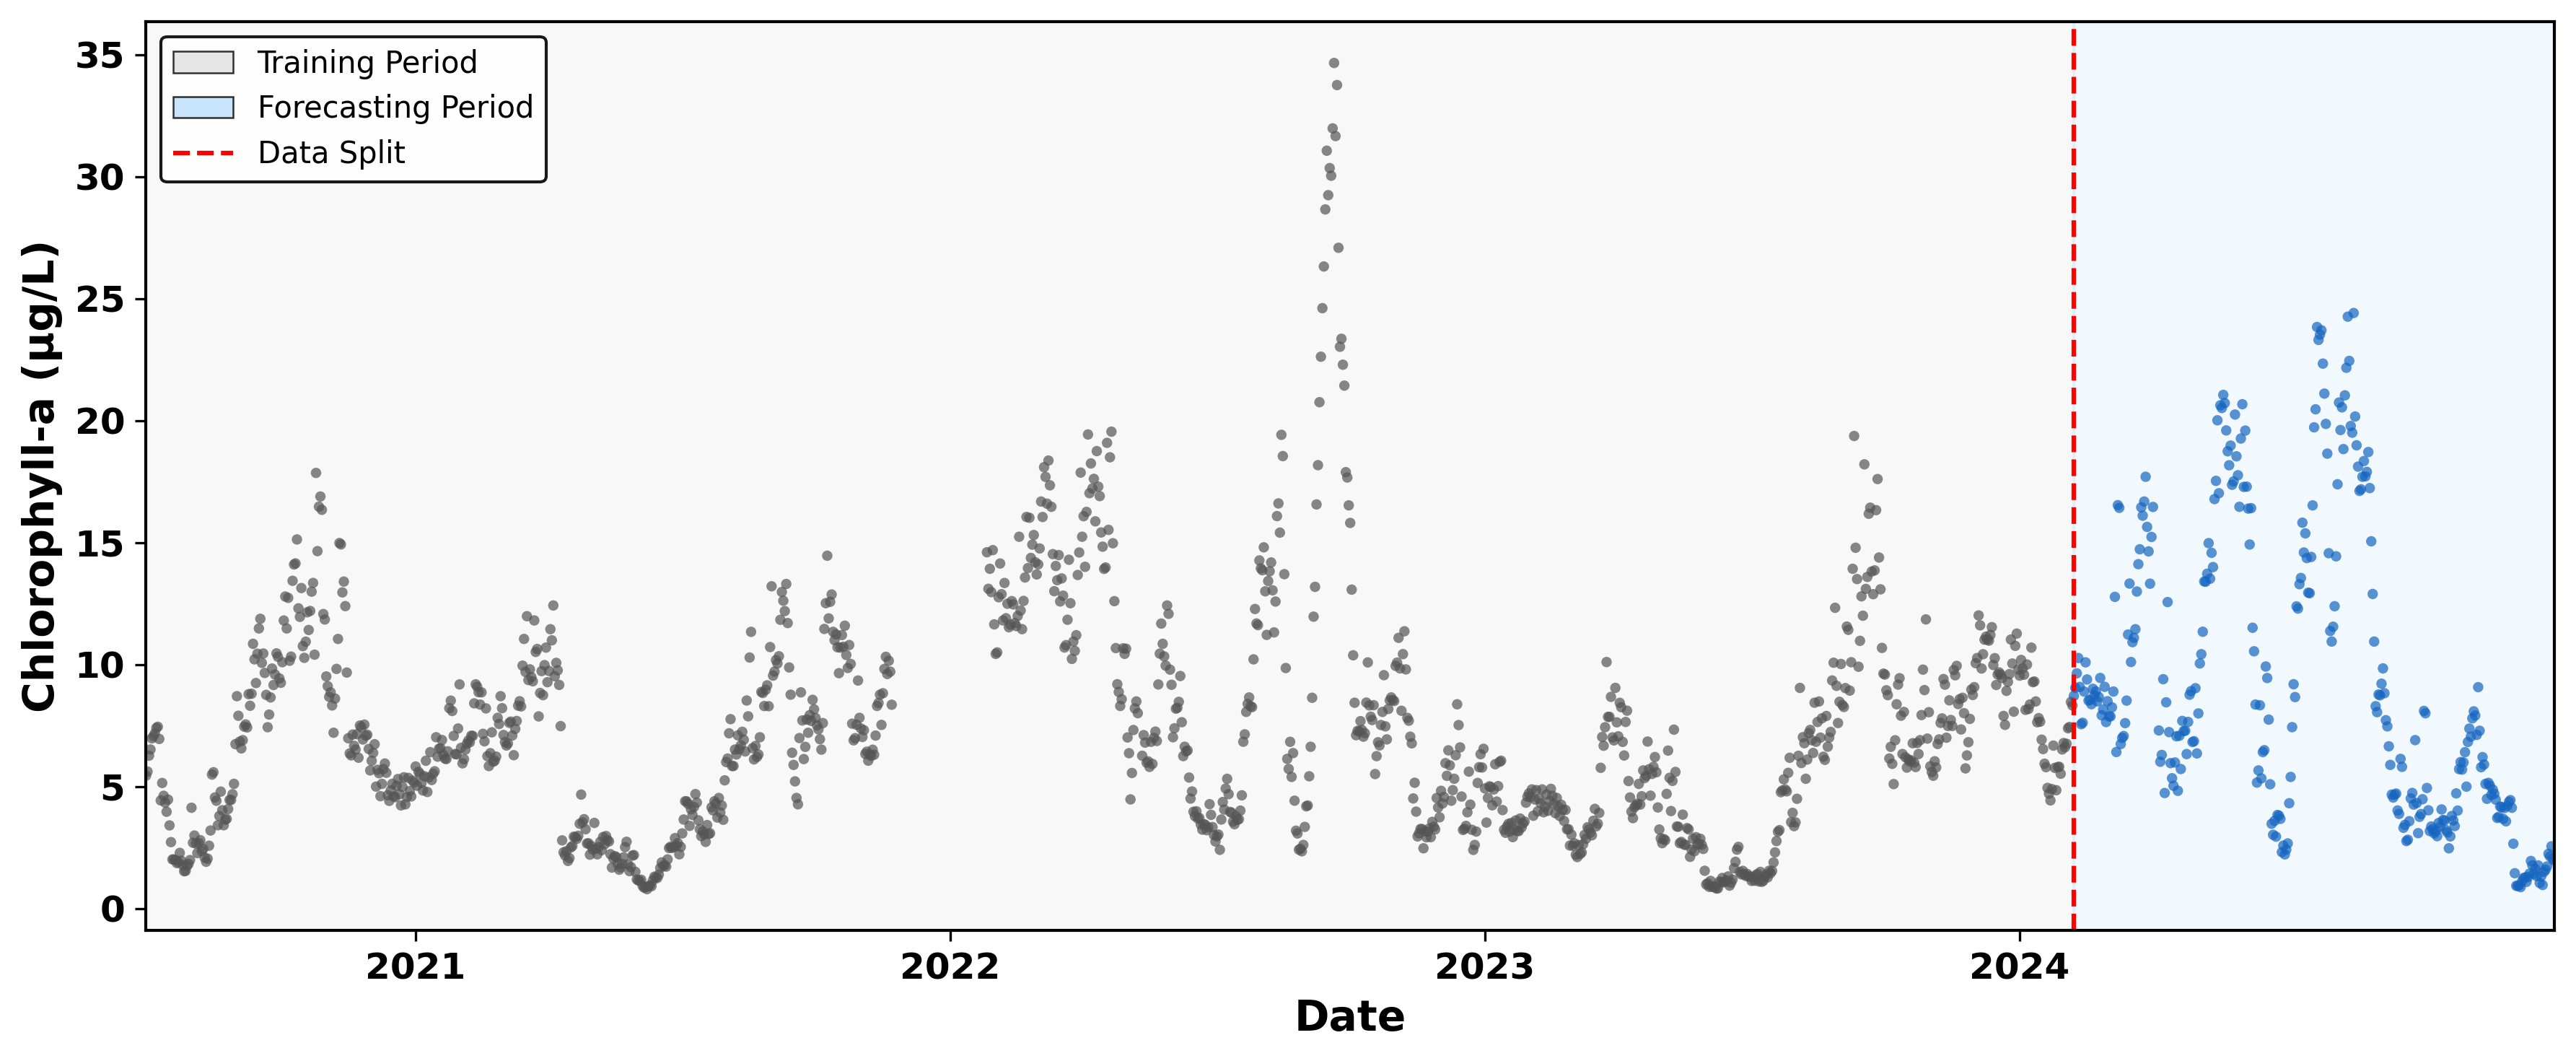

 Saved Chlorophyll-a scatter plot
 CREATING SUPERVISED DATASET - DIRECT MULTI-HORIZON

 INPUT:
 Shape: (1645, 9)
 Date range: 2020-07-01 -> 2024-12-31

 Creating 7-day forecast targets...

 FEATURES (9 total):

 TARGETS (7 horizons):
 SUPERVISED DATASET CREATED


In [3]:
# ------------------------------------------------------------
# CHLOROPHYLL-A SCATTER PLOT and DATA CURATION
# ------------------------------------------------------------
split_idx = int(len(raw_df) * 0.8)
split_date = raw_df.index[split_idx]
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
data = raw_df[TARGET_COLUMN].dropna()
train_data = data[data.index < split_date]
test_data = data[data.index >= split_date]

ax.set_xlim(data.index.min(),data.index.max())

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


# Background shading
ax.axvspan(raw_df.index.min(), split_date, color='#E0E0E0', alpha=0.2, label='Training Period')
ax.axvspan(split_date, raw_df.index.max(), color='#BBDEFB', alpha=0.2, label='Forecasting Period')
# Split line
ax.axvline(split_date, color='red', linestyle='--', linewidth=1.5, label='Data Split')
# Scatter
ax.scatter(train_data.index, train_data.values, s=12, color='#555555', alpha=0.7, edgecolors='none')
ax.scatter(test_data.index, test_data.values, s=12, color='#1565C0', alpha=0.7, edgecolors='none')
# Labels
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Chlorophyll-a (µg/L)', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontweight('bold')
legend= ax.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='black')
for patch in legend.get_patches():
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
ax.grid(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/exploratory_analysis/chla_timeseries_scatter.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f" Saved Chlorophyll-a scatter plot")

# ------------------------------------------------------------
# CREATE SUPERVISED DATASET
# ------------------------------------------------------------

def create_supervised_dataset_raw(df, target_col, horizons):
    """
    Creates multi-step forecasting targets.
    """
    print(" CREATING SUPERVISED DATASET - DIRECT MULTI-HORIZON")

    print(f"\n INPUT:")
    print(f" Shape: {df.shape}")
    print(f" Date range: {df.index.min().date()} -> {df.index.max().date()}")

    # Create multi-horizon targetS
    print(f"\n Creating {horizons}-day forecast targets...")
    target_forecasts = {}
    for h in range(1, horizons + 1):
        target_forecasts[f"{target_col}_t+{h}"] = df[target_col].shift(-h)

    df_forecasts = pd.DataFrame(target_forecasts, index=df.index)

    # Combine features and targets
    df_supervised = pd.concat([df, df_forecasts], axis=1)
    target_cols = df_forecasts.columns.tolist()

    # Drop rows where ANY target is missing
    before_drop = len(df_supervised)
    df_clean = df_supervised.dropna(subset=target_cols)
    after_drop = len(df_clean)

    # Separate X and y
    feature_cols = df.columns.tolist()
    X = df_clean[feature_cols]
    y = df_clean[target_cols]
    X_missing = X.isnull().sum().sum()
    total_X_cells = X.shape[0] * X.shape[1]


    print(f"\n FEATURES ({len(feature_cols)} total):")
    print(f"\n TARGETS ({len(target_cols)} horizons):")
    print(" SUPERVISED DATASET CREATED")
    return X, y

# Create supervised dataset
X, y = create_supervised_dataset_raw(raw_df, TARGET_COLUMN, FORECAST_HORIZONS)



## 4. Train/test split and preprocessing

Chronological 80/20 split (no shuffling).

In [5]:
# ------------------------------------------------------------
# TRAIN-TEST SPLIT (CHRONOLOGICAL) and PREPROCESSING
# ------------------------------------------------------------

print(" CHRONOLOGICAL TRAIN-TEST SPLIT")

# Split data
split_point = int(np.floor(len(X) * TRAIN_RATIO))

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"\n Split Ratio: {int(TRAIN_RATIO*100)}/{100-int(TRAIN_RATIO*100)}")
print(f"\nTrain Set:")
print(f" Period: {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f" Samples: {len(X_train):,}")

print(f"\nTest Set:")
print(f" Period: {X_test.index.min().date()} -> {X_test.index.max().date()}")
print(f" Samples: {len(X_test):,}")

print(" CHRONOLOGICAL SPLIT COMPLETE")

# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

print("Preprocessing started!")
# Create simple pipeline: scaling only
preprocessor = Pipeline([
    ('scaler', StandardScaler()) # Skips NaN in mean/std calculation
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed,
    index=X_train.index,
    columns=X_train.columns
)
X_test_processed = pd.DataFrame(
    X_test_processed,
    index=X_test.index,
    columns=X_test.columns
)
print("Preprocessing complete!")

 CHRONOLOGICAL TRAIN-TEST SPLIT

 Split Ratio: 80/20

Train Set:
 Period: 2020-07-01 -> 2024-02-08
 Samples: 1,240

Test Set:
 Period: 2024-02-09 -> 2024-12-24
 Samples: 311
 CHRONOLOGICAL SPLIT COMPLETE
Preprocessing started!
Preprocessing complete!


## 5. Hyperparameter optimisation

Optuna with TPE sampler, 50 trials, 5-fold time-series cross-validation. Optimizes for RMSE across all 7 horizons.

In [6]:
# ------------------------------------------------------------
# HYPERPARAMETER OPTIMIZATION (OPTUNA)
# ------------------------------------------------------------

def objective(trial, X, y):
    """
    Optuna objective function with regularization
    """

    params = {
        "objective": "reg:squarederror",
        "random_state": SEED,
        "n_jobs": 1,
        "tree_method": "hist",
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "gamma": trial.suggest_float("gamma", 0.5, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 2.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.8),
    }

    estimator = MultiOutputRegressor(xgb.XGBRegressor(**params))

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    rmses = []

    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        estimator.fit(X_tr, y_tr)
        y_pred = estimator.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(rmse)

    return float(np.mean(rmses))
print(" HYPERPARAMETER OPTIMIZATION")

print(f"\n Starting Optuna with {OPTUNA_TRIALS} trials and {CV_SPLITS}-fold CV...")
print(f" This will take approximately 8-10 minutes...")
print(f" Progress bar will show below:\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)

study.optimize(
    lambda trial: objective(trial, X_train_processed, y_train),
    n_trials=OPTUNA_TRIALS,
    show_progress_bar=True
)

print("\n HPO Complete!")
print("\n BEST TRIAL:")
print(f" RMSE (CV mean): {study.best_value:.4f} µg/L")
print(f"\n Best parameters (Enhanced Regularization):")
for k, v in study.best_params.items():
    print(f" {k}: {v}")

# Save trials
trials_df = study.trials_dataframe()
trials_df.to_csv(f'{OUTPUT_DIR}/optuna_trials.csv', index=False)
print(f"\n Saved: {OUTPUT_DIR}/optuna_trials.csv")


 HYPERPARAMETER OPTIMIZATION

 Starting Optuna with 50 trials and 5-fold CV...
 This will take approximately 8-10 minutes...
 Progress bar will show below:



  0%|          | 0/50 [00:00<?, ?it/s]


 HPO Complete!

 BEST TRIAL:
 RMSE (CV mean): 3.1174 µg/L

 Best parameters (Enhanced Regularization):
 n_estimators: 487
 max_depth: 6
 learning_rate: 0.02300490018031172
 min_child_weight: 50
 gamma: 1.3934283815625819
 reg_alpha: 9.662456565217486
 reg_lambda: 7.609300763150078
 subsample: 0.7058896527544977
 colsample_bytree: 0.798407607931189

 Saved: ./BVR_Forecasting_Results/optuna_trials.csv


## 6. Model training and evaluation


In [7]:
# ------------------------------------------------------------
# TRAIN FINAL MODEL WITH BEST PARAMETERS
# ------------------------------------------------------------

print(" TRAINING FINAL MODEL")

best_params = study.best_params
final_xgboost = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_params
)

final_model = MultiOutputRegressor(final_xgboost)
final_model.fit(X_train_processed, y_train)

print(" Model trained successfully!")
print(f"\n Model Structure:")
print(f" Type: MultiOutputRegressor")
print(" FINAL MODEL TRAINED AND READY FOR EVALUATION")

# ------------------------------------------------------------
# MODEL EVALUATION
# ------------------------------------------------------------

def evaluate_model(model, X_test, y_test):
    """Calculate performance metrics for each horizon."""

    y_pred = model.predict(X_test)
    metrics_rows = []
    print(" PERFORMANCE BY HORIZON")


    for i in range(y_test.shape[1]):
        y_true_h = y_test.iloc[:, i]
        y_pred_h = y_pred[:, i]

        rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
        mae = mean_absolute_error(y_true_h, y_pred_h)
        corr = np.corrcoef(y_true_h, y_pred_h)[0, 1]

        metrics_rows.append({
            "Horizon": f"{i+1}-day",
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
            "Correlation": round(corr, 4),
        })

        #print(f"Horizon {i+1}: RMSE={rmse:.4f}, MAE={mae:.4f},Corr={corr:.4f}")

    return pd.DataFrame(metrics_rows)

# Evaluate on test set
metrics_df = evaluate_model(final_model, X_test_processed, y_test)

print(f"\n SUMMARY STATISTICS:")
#print(f" Average RMSE: {metrics_df['RMSE'].mean():.4f} µg/L")
#print(f" Average MAE: {metrics_df['MAE'].mean():.4f} µg/L")
#print(f" Average Corr: {metrics_df['Correlation'].mean():.4f}")

print(" MODEL EVALUATION COMPLETE")

# Save metrics
metrics_df.to_csv(f'{OUTPUT_DIR}/test_metrics_by_horizon.csv', index=False)
print(f"\n Saved: {OUTPUT_DIR}/test_metrics_by_horizon.csv")

 TRAINING FINAL MODEL
 Model trained successfully!

 Model Structure:
 Type: MultiOutputRegressor
 FINAL MODEL TRAINED AND READY FOR EVALUATION
 PERFORMANCE BY HORIZON

 SUMMARY STATISTICS:
 MODEL EVALUATION COMPLETE

 Saved: ./BVR_Forecasting_Results/test_metrics_by_horizon.csv


## 7. SHAP feature attribution

SHAP beesworm for the 7-day horizon model and a stacked proportional importance chart across all 7 horizons.

 7-DAY SHAP ANALYSIS + STACKED PROPORTIONAL IMPORTANCE
 Computing SHAP values for 7-day horizon...
 Generating 7-day SHAP summary plot...


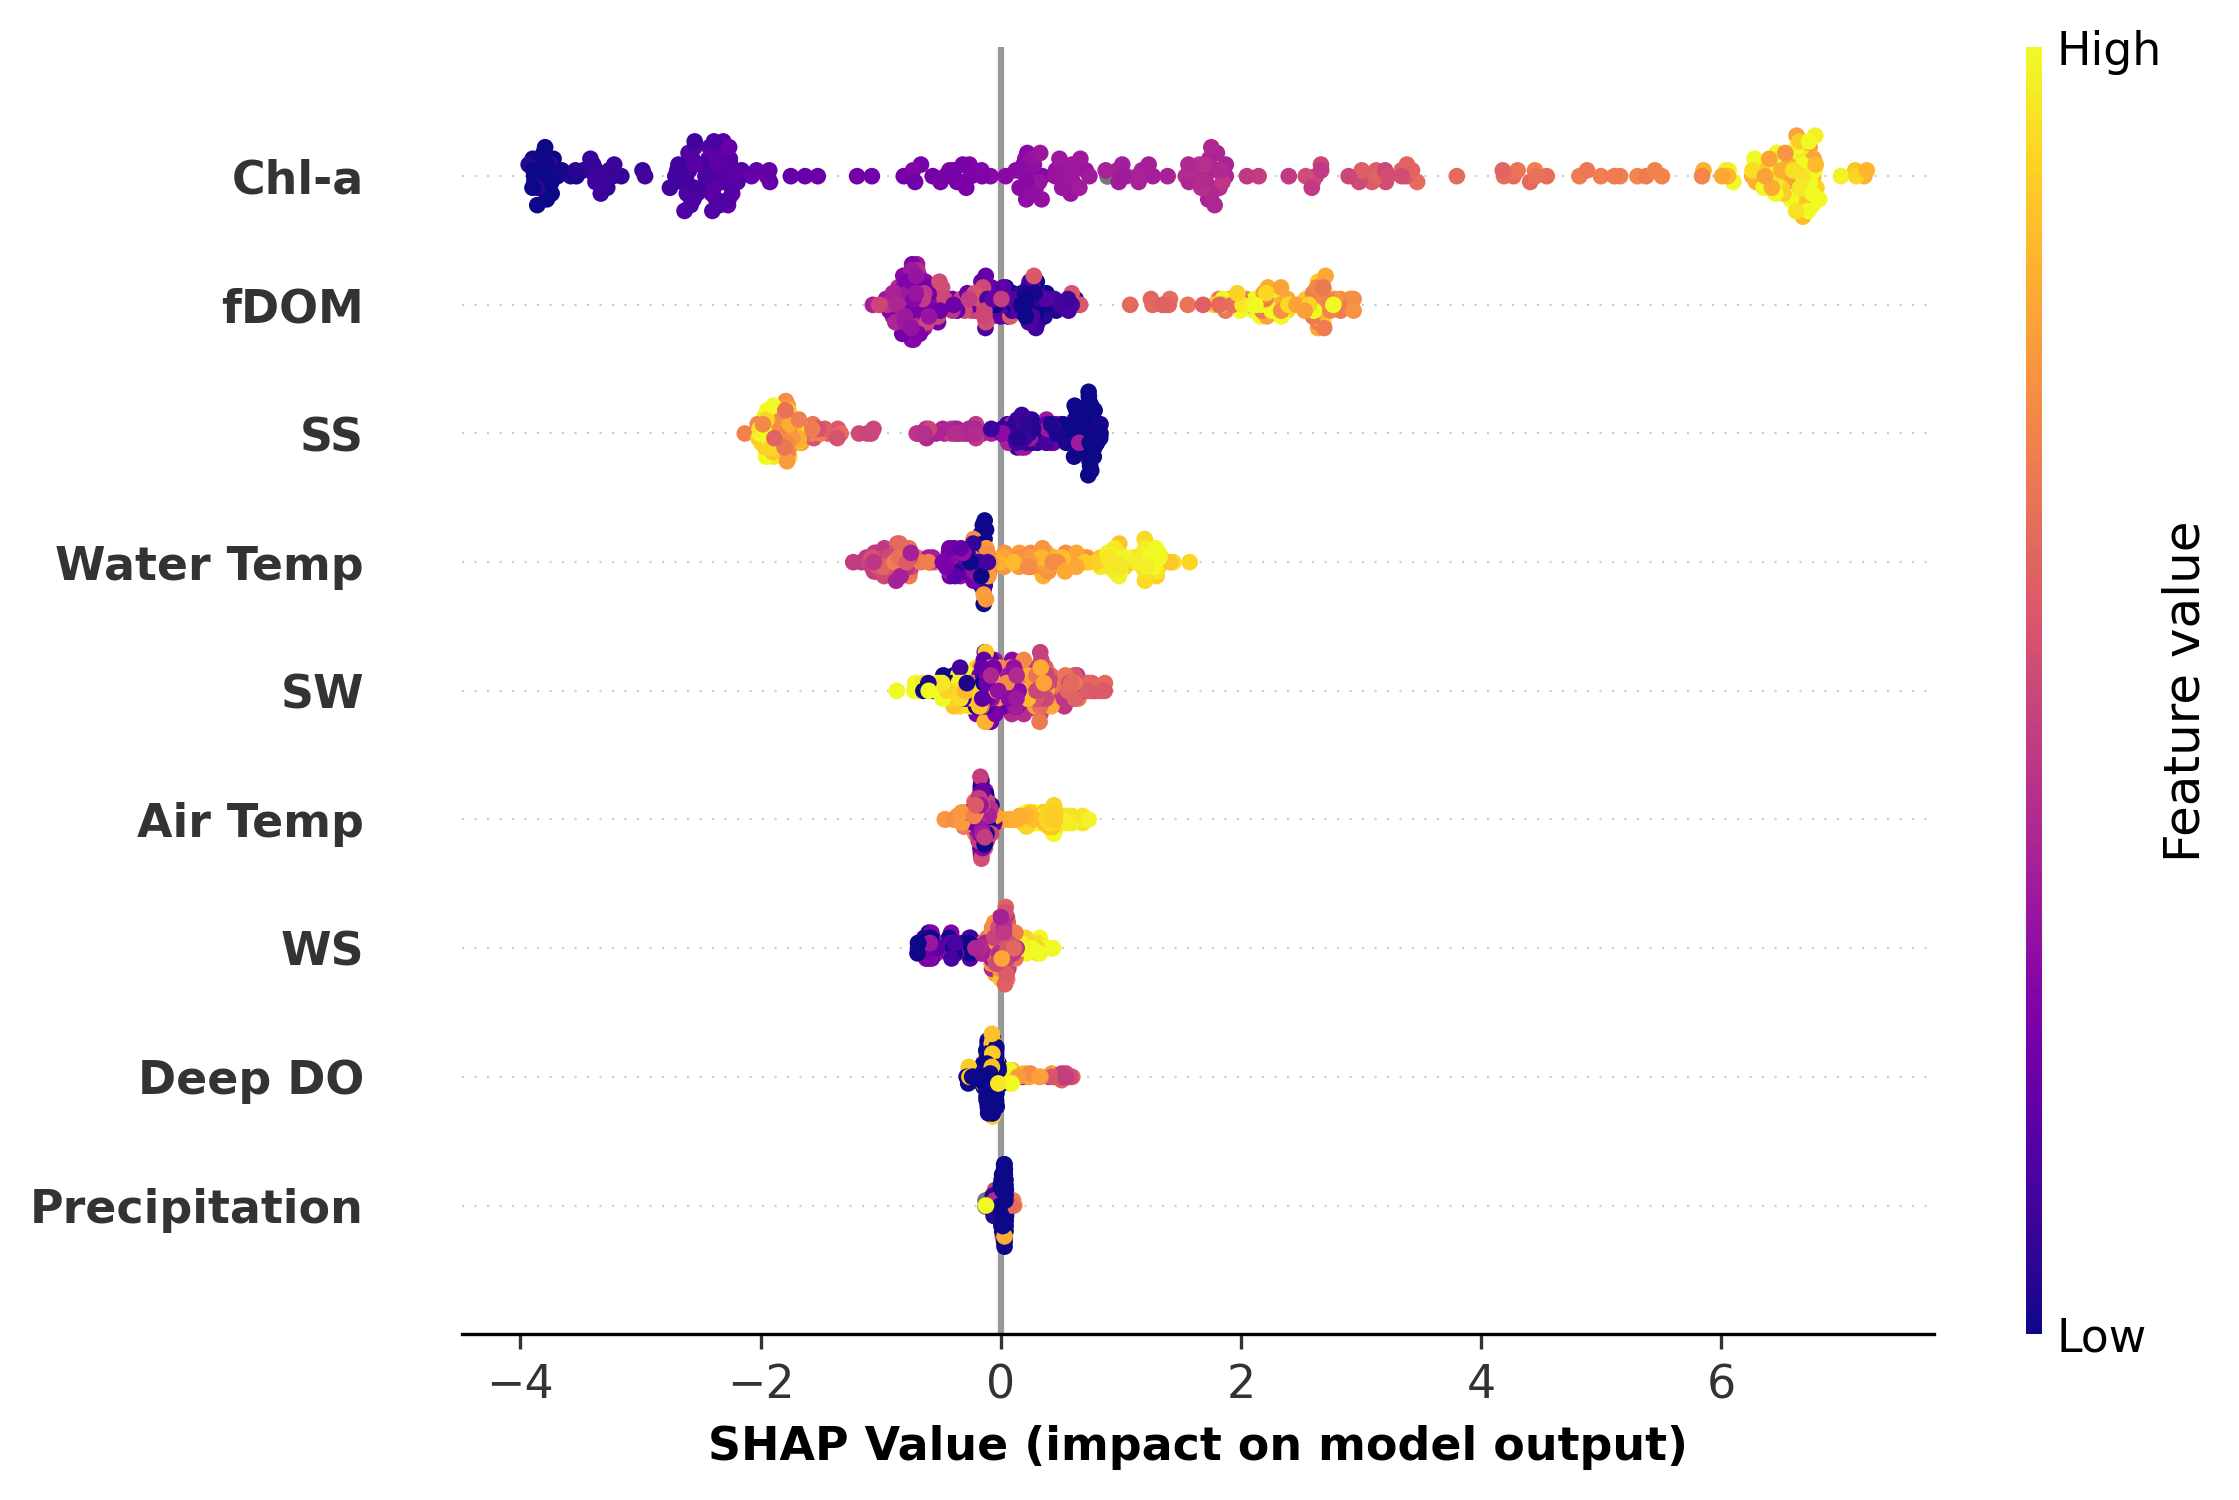

 Computing SHAP values for all horizons...
 Generating stacked proportional importance chart...


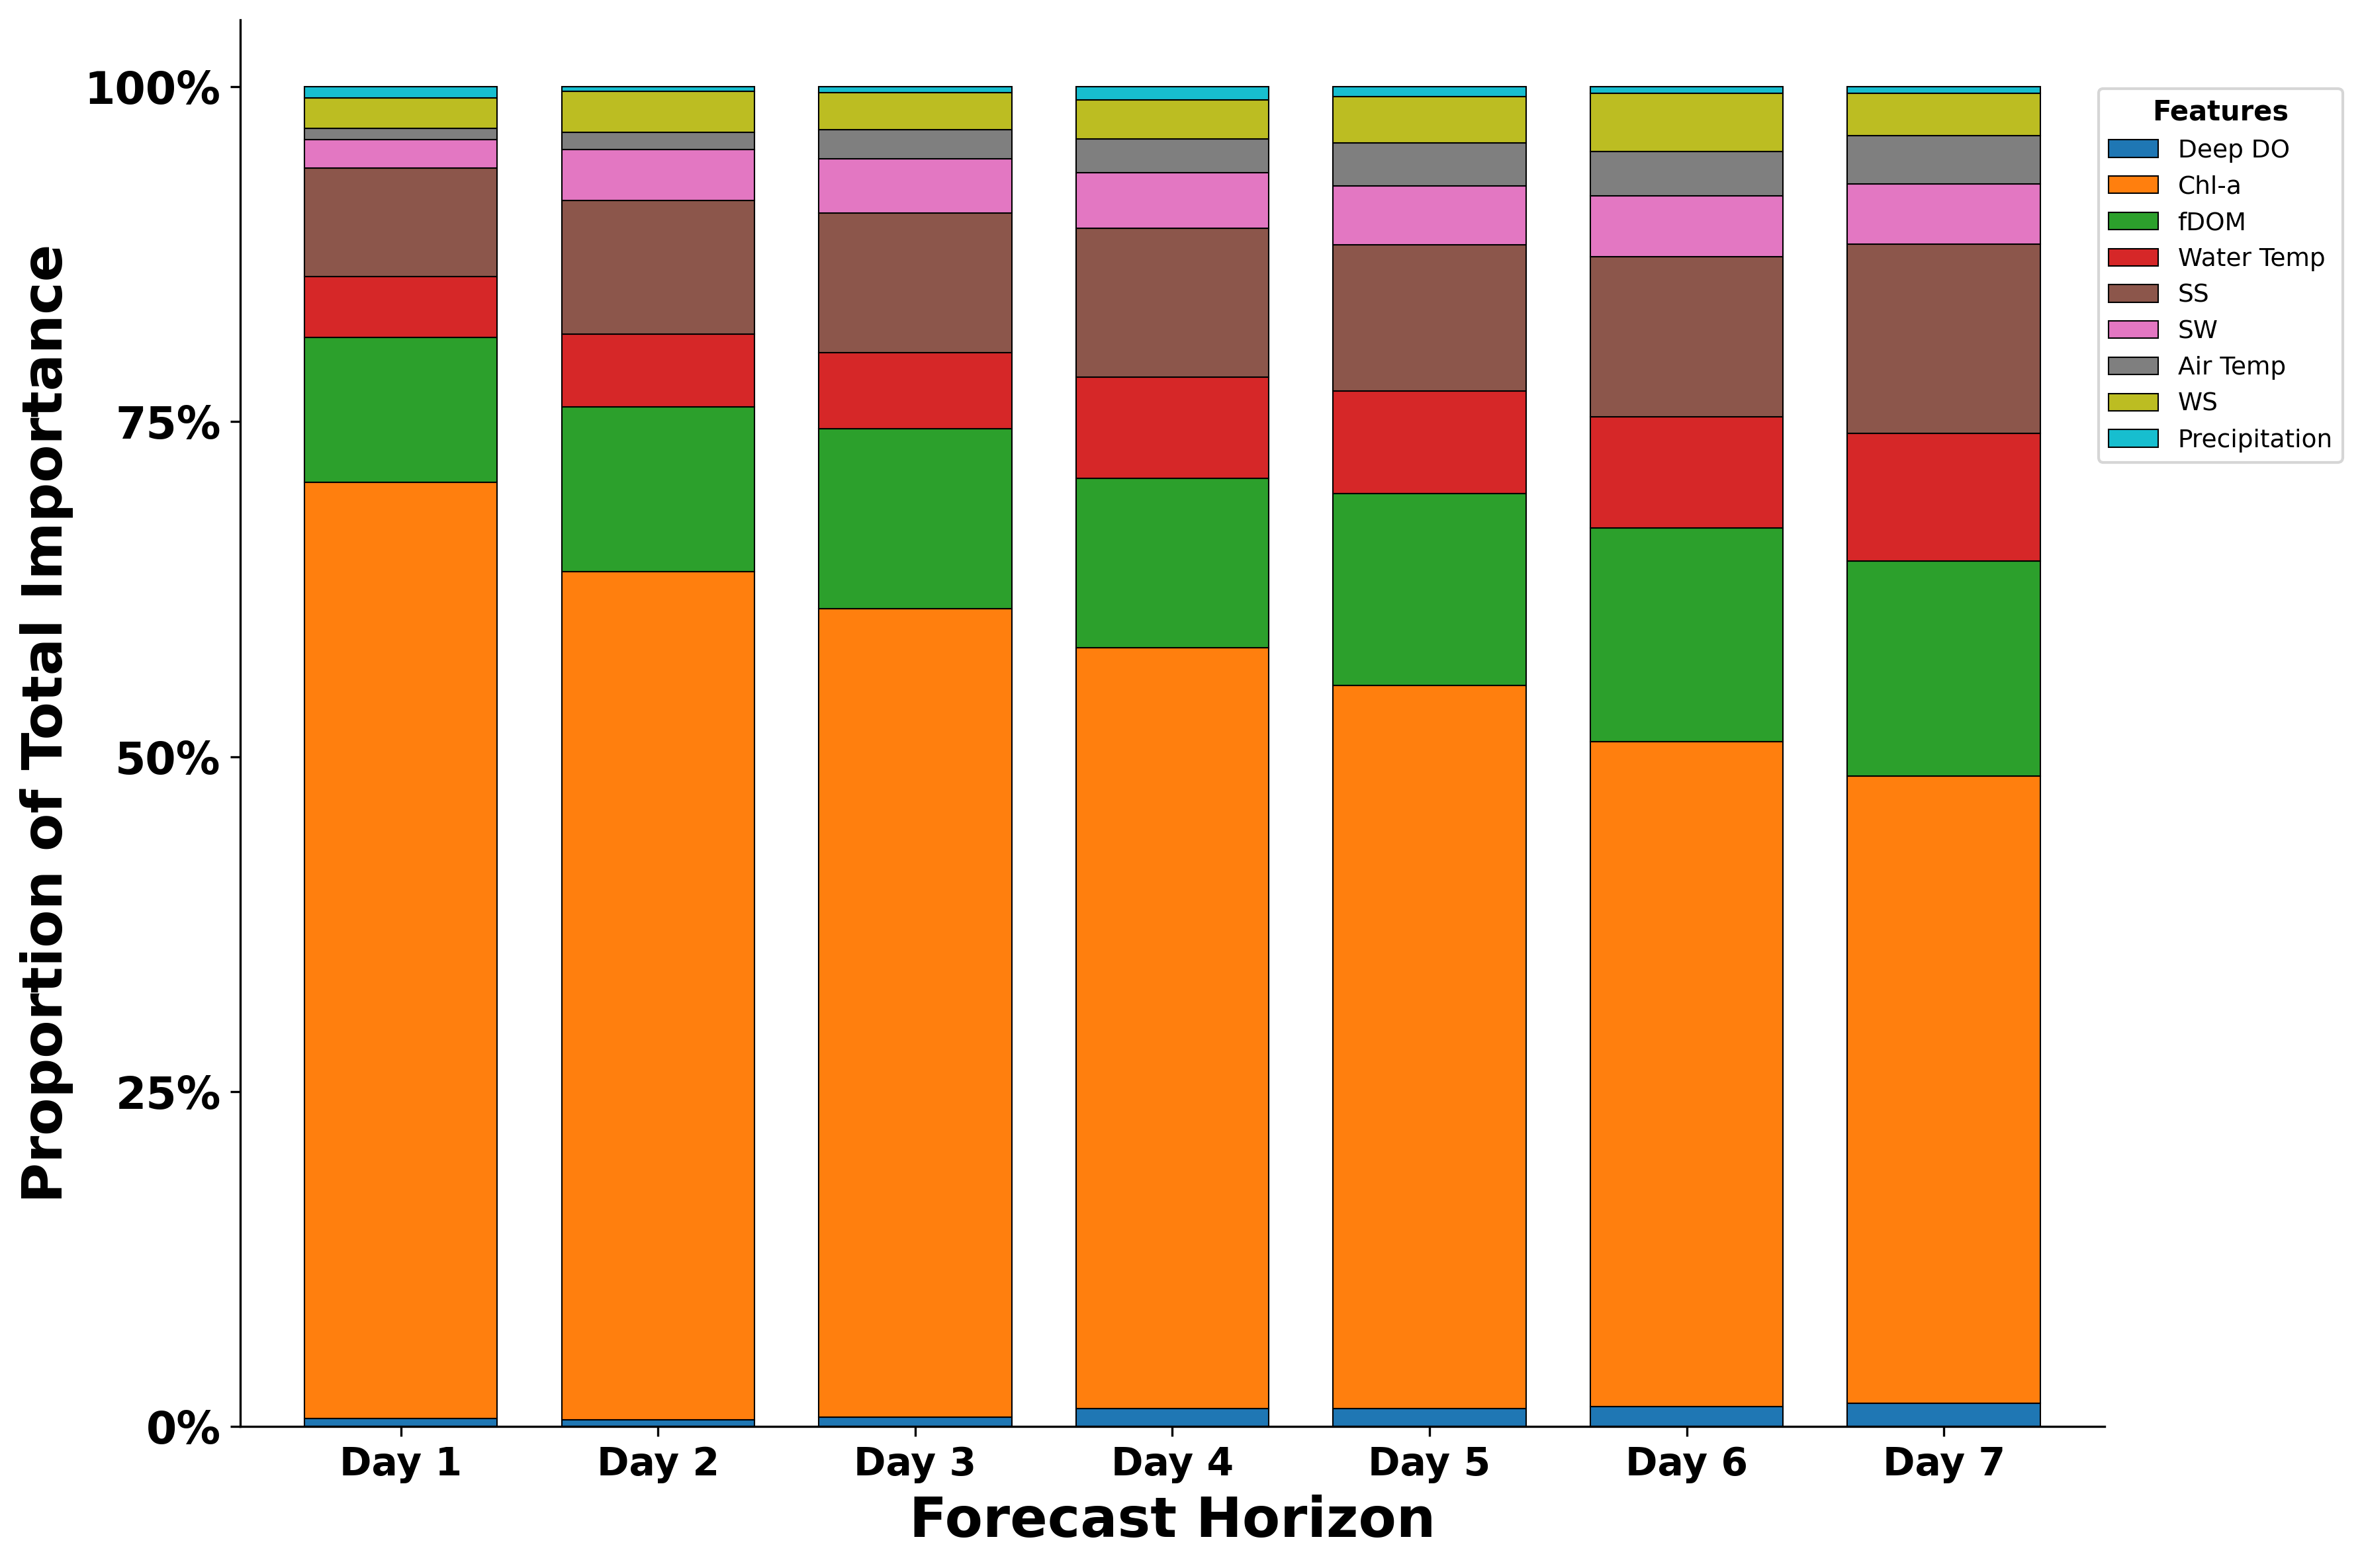

 Saved: ./BVR_Forecasting_Results/shap_stacked_proportions.png
 ANALYSIS COMPLETE (Saved figures in current directory)

 FILES GENERATED:
 2. shap_stacked_proportions.png


In [8]:
# ------------------------------------------------------------
# SHAP 7-DAY ANALYSIS + STACKED PROPORTIONAL IMPORTANCE
# ------------------------------------------------------------

print(" 7-DAY SHAP ANALYSIS + STACKED PROPORTIONAL IMPORTANCE")


# ============================================================================
# Feature Abbreviation Map
# ============================================================================
FEATURE_ABBREV_MAP = {
    'BVR_mean_EXOChla_ugL_1.5': 'Chl-a',
    'BVR_mean_EXOfDOM_QSU_1.5': 'fDOM',
    'BVR_mean_EXOTemp_C_1.5': 'Water Temp',
    'BVR_mean_schmidt_stability': 'SS',
    'BVR_mean_RDOsat_percent_13': 'Deep DO',
    'mean_ShortwaveRadiationUp_Average_W_m2': 'SW',
    'mean_AirTemp_C_Average': 'Air Temp',
    'mean_WindSpeed_Average_m_s': 'WS',
    'sum_Rain_Total_mm': 'Precipitation'
}

# ============================================================================
# Compute SHAP for 7-Day Horizon ONLY
# ============================================================================
print(" Computing SHAP values for 7-day horizon...")

# Get 7-day model (last horizon)
model_7d = final_model.estimators_[-1]
explainer_7d = shap.TreeExplainer(model_7d)

X_shap = X_test_processed
shap_values_7d = explainer_7d.shap_values(X_shap) # shape: (N_samples, N_features)


# ============================================================================
# Get Feature Importance Ranking (7-day)
# ============================================================================
mean_abs_shap_7d = np.abs(shap_values_7d).mean(axis=0)

shap_importance_7d = pd.DataFrame({
    'Feature': X_test_processed.columns,
    'Feature_Abbrev': [FEATURE_ABBREV_MAP.get(f, f) for f in X_test_processed.columns],
    'Mean_|SHAP|': mean_abs_shap_7d
}).sort_values('Mean_|SHAP|', ascending=False)

# ============================================================================
# SHAP Summary Plot (7-Day)
# ============================================================================
print(" Generating 7-day SHAP summary plot...")

plt.figure(figsize=(10, 7), dpi=300)
shap.summary_plot(
    shap_values_7d,
    X_shap,
    show=False,
    max_display=10,
    cmap=plt.get_cmap('plasma')
)

# Apply abbreviated y-tick labels
ax = plt.gca()
yticklabels = ax.get_yticklabels()
new_labels = [FEATURE_ABBREV_MAP.get(lbl.get_text(), lbl.get_text())
              for lbl in yticklabels]
ax.set_yticklabels(new_labels, fontweight='bold', fontsize=11)

plt.xlabel('SHAP Value (impact on model output)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_7day_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Compute SHAP for ALL Horizons (for Stacked Bar Chart)
# ============================================================================
print(" Computing SHAP values for all horizons...")
mean_abs_shap_all_horizons = []

for h_idx in range(FORECAST_HORIZONS):
    # Get model for current horizon
    model_h = final_model.estimators_[h_idx]
    explainer_h = shap.TreeExplainer(model_h)

    # Compute SHAP values
    shap_values_h = explainer_h.shap_values(X_shap)

    # Get mean absolute SHAP for this horizon
    mean_abs_shap_h = np.abs(shap_values_h).mean(axis=0)
    mean_abs_shap_all_horizons.append(mean_abs_shap_h)

mean_abs_shap = np.array(mean_abs_shap_all_horizons)

# ============================================================================
# Stacked Bar Chart - Relative Feature Importance
# ============================================================================
print(" Generating stacked proportional importance chart...")

n_h, n_f = mean_abs_shap.shape
feature_names_full = list(X_test_processed.columns)[:n_f] # align to matrix width
feature_names_abbrev = [FEATURE_ABBREV_MAP.get(f, f) for f in feature_names_full]
horizon_labels = [f'Day {i+1}' for i in range(n_h)]

# Normalize SHAP values to proportions (row-wise per horizon)
normalized_shap = mean_abs_shap / mean_abs_shap.sum(axis=1, keepdims=True)

# DataFrame with abbreviated names
df_normalized = pd.DataFrame(
    normalized_shap,
    index=horizon_labels,
    columns=feature_names_abbrev
)

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
df_normalized.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='tab10',
    width=0.75,
    edgecolor='black',
    linewidth=0.5
)

#             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Forecast Horizon', fontsize=20, fontweight='bold')
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(14)
ax.set_ylabel('Proportion of Total Importance', fontsize=20, fontweight='bold')
ax.set_xticklabels(horizon_labels, rotation=0, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=16, fontweight='bold')
ax.legend(title='Features', bbox_to_anchor=(0.99, 0.96), loc='upper left',
          frameon=True, shadow=False, fontsize=9,
          title_fontproperties={'weight': 'bold', 'size': 10})
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_stacked_proportions.png', dpi=600, bbox_inches='tight')
plt.show()
print(f" Saved: {OUTPUT_DIR}/shap_stacked_proportions.png")

# ============================================================================
# Summary
# ============================================================================
print(" ANALYSIS COMPLETE (Saved figures in current directory)")
print("\n FILES GENERATED:")
print(" 2. shap_stacked_proportions.png")


## 8. Performance curves

RMSE as a function of forecast horizon for train and test sets. Shows how predictability degrades with lead time.

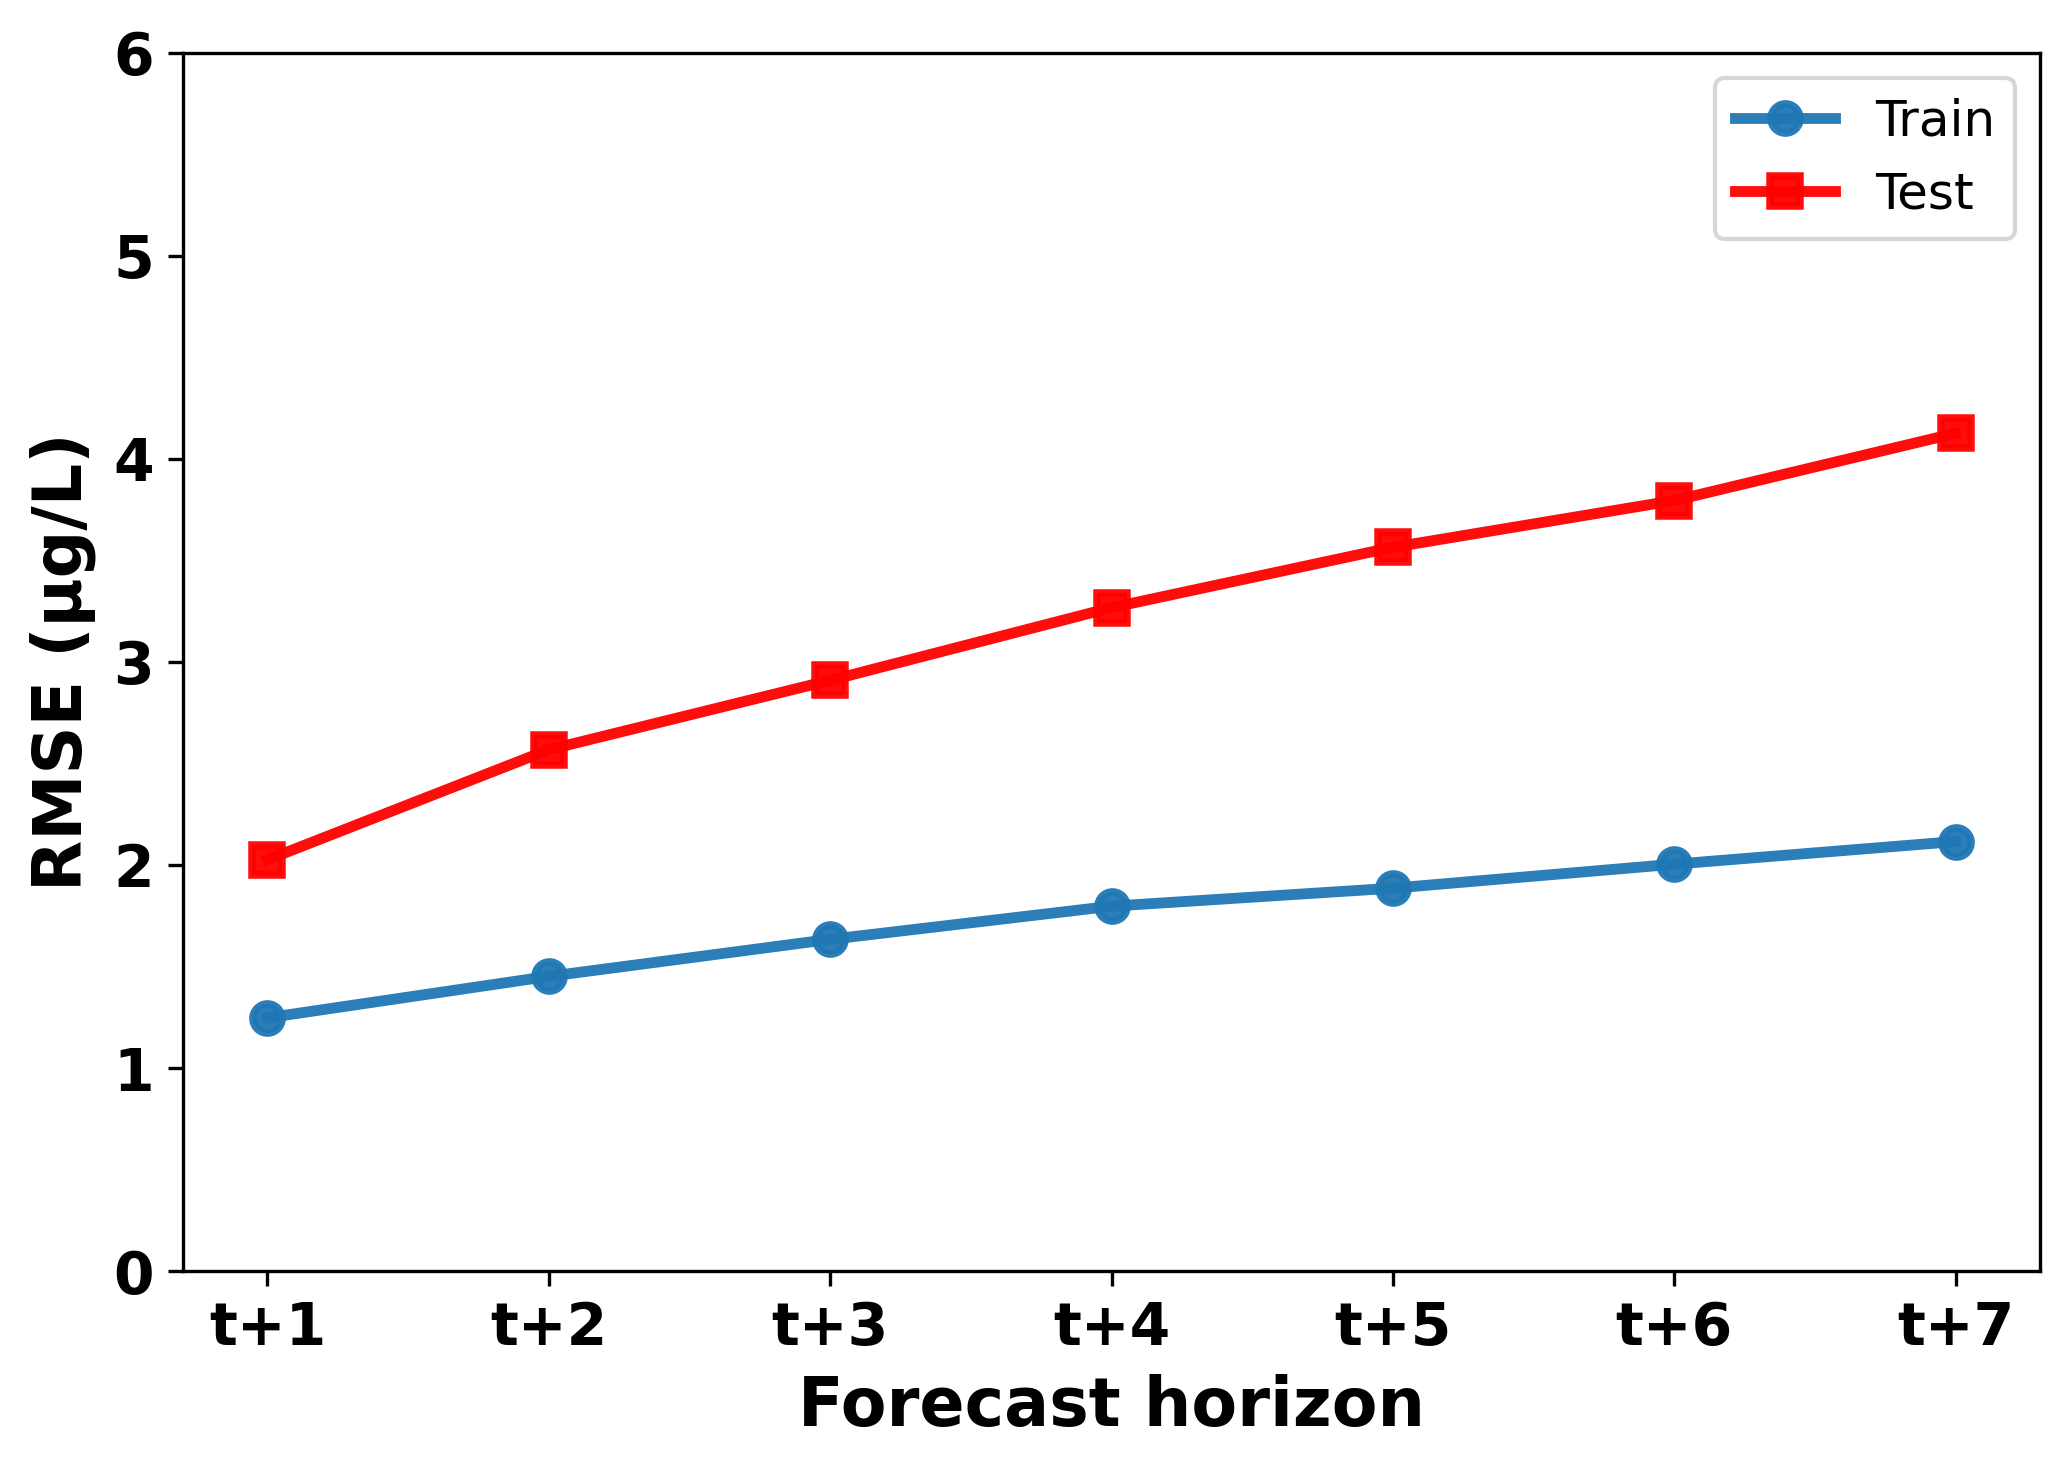

 Saved: ./BVR_Forecasting_Results/performance_curves_rmse_train_test.png


In [9]:
# ============================================================================
# LINE PERFORMANCE CURVES ACROSS HORIZONS (TRAIN VS TEST)
# PURPOSE: Show horizon-wise RMSE trends across forecast horizons
# ============================================================================

# Compute predictions for train and test sets
y_train_pred = final_model.predict(X_train_processed)
y_test_pred = final_model.predict(X_test_processed)

# Calculate RMSE for each forecast horizon
train_rmse = []
test_rmse = []
for i in range(FORECAST_HORIZONS):
    train_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[:, i], y_train_pred[:, i])))
    test_rmse.append(np.sqrt(mean_squared_error(y_test.iloc[:, i], y_test_pred[:, i])))

h_idx = np.arange(1, FORECAST_HORIZONS + 1)
h_labels = [f"t+{i}" for i in h_idx]

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.plot(
    h_idx, train_rmse,
    linestyle="-", color="#1f77b4", linewidth=2.6, marker="o", markersize=7,
    markerfacecolor="#1f77b4", markeredgewidth=1.8,
    label="Train", alpha=0.95
)
ax.plot(
    h_idx, test_rmse,
    linestyle="-", color="red", linewidth=2.6, marker="s", markersize=7,
    markerfacecolor="red", markeredgewidth=1.8,
    label="Test", alpha=0.95
)

ax.set_xticks(h_idx)
ax.set_xticklabels(h_labels)
ax.set_ylim(0, 6)
ax.set_xlabel("Forecast horizon", fontsize=16, fontweight="bold")
ax.set_ylabel("RMSE (µg/L)", fontsize=16, fontweight="bold")
ax.tick_params(axis="both", labelsize=14)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight("bold")
ax.legend(frameon=True, fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()

out_path = f"{OUTPUT_DIR}/performance_curves_rmse_train_test.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f" Saved: {out_path}")

## 9. Instance-level explanations

Two-panel figure for selected test instances: Panel (a) observed vs predicted with 90% bootstrap CI, Panel (b) SHAP waterfall plots at Day 1, Day 4, and Day 7.

In [10]:
# ------------------------------------------------------------
# TWO-PANEL COMBINED PLOTS (time series + waterfalls)
# ------------------------------------------------------------
# ------------------------------------------------------------
# Matplotlib settings
# ------------------------------------------------------------
import matplotlib
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

matplotlib.rcdefaults()
plt.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size'         : 10,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 13,
    'axes.linewidth'    : 1.0,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'xtick.major.width' : 1.0,
    'ytick.major.width' : 1.0,
    'xtick.major.size'  : 3.5,
    'ytick.major.size'  : 3.5,
    'xtick.direction'   : 'out',
    'ytick.direction'   : 'out',
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.9,
    'figure.dpi'        : 300,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
})

print('GENERATING TWO-PANEL PLOTS (TIME SERIES + WATERFALLS)')

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
INSTANCES = [
    {
        'date': '2024-06-04',
        'y_min': 2,
        'y_max': 22,
        'y_step': 4,
        'tag': 'pre_bloom',
        'legend_loc': 'lower left'
    },
    {
        'date': '2024-08-31',
        'y_min': 6,
        'y_max': 12,
        'y_step': 2,
        'tag': 'bloom_peak',
        'legend_loc': 'upper left'
    },
]


WF_HORIZONS = [0, 3, 6]
WF_LABELS   = ['Day 1', 'Day 4', 'Day 7']

ANNOTATION_COLOR = '#555555'
OBS_COLOR        = '#1F5A94'
PRED_COLOR       = '#B44441'
CI_FILL_COLOR    = '#B8B8B8'
CI_EDGE_COLOR    = '#7F7F7F'

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
required_globals = [
    'X_test_processed',
    'X_train_processed',
    'y_train',
    'y_test',
    'best_params',
    'final_model'
]

missing = [name for name in required_globals if name not in globals()]
if missing:
    raise ValueError(f'Missing required variables in memory: {missing}')

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
y_test_pred = final_model.predict(X_test_processed)

y_test_pred = np.asarray(y_test_pred)
y_test_arr  = np.asarray(y_test)

if y_test_pred.ndim != 2:
    raise ValueError(f'y_test_pred must be 2D, got shape {y_test_pred.shape}')

n_horizons = y_test_pred.shape[1]
h_arr      = np.arange(1, n_horizons + 1)
test_dates = pd.to_datetime(X_test_processed.index)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Bootstrap ensemble for confidence interval
# ------------------------------------------------------------
B_UQ   = 10
SEED   = 42
N_test = len(X_test_processed)

if 'all_boot_preds' not in globals() or all_boot_preds.shape != (N_test, n_horizons, B_UQ):
    print(f'  Training B={B_UQ} bootstrap ensemble for CI bands...')
    all_boot_preds = np.zeros((N_test, n_horizons, B_UQ), dtype=np.float32)

    for b in range(B_UQ):
        X_b, y_b = resample(
            X_train_processed,
            y_train,
            replace=True,
            random_state=SEED + b
        )

        mdl = MultiOutputRegressor(
            xgb.XGBRegressor(
                objective='reg:squarederror',
                tree_method='hist',
                **best_params,
                random_state=SEED + b,
                n_jobs=-1
            )
        )

        mdl.fit(X_b, y_b)
        all_boot_preds[:, :, b] = mdl.predict(X_test_processed)
        print(f'    Model {b + 1}/{B_UQ} done')
else:
    print('  Reusing existing bootstrap ensemble for CI bands...')

print('  Bootstrap ensemble ready.\n')

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def _hide_shap_aux_axes_labels(ax_main, fig):
    """
    making function to tweak the plot/visualiz the plot/visualisation
    to avoid overlapping and clutter of labels.
    """
    main_pos = ax_main.get_position()

    for a in fig.get_axes():
        if a is ax_main:
            continue

        apos = a.get_position()
        same_box = (
            abs(apos.x0 - main_pos.x0) < 0.01 and
            abs(apos.y0 - main_pos.y0) < 0.01 and
            abs(apos.width - main_pos.width) < 0.01 and
            abs(apos.height - main_pos.height) < 0.01
        )

        if same_box:
            a.set_xlabel('')
            a.set_ylabel('')
            a.tick_params(axis='x', which='both',
                          bottom=False, top=False,
                          labelbottom=False, labeltop=False)
            a.tick_params(axis='y', which='both',
                          left=False, right=False,
                          labelleft=False, labelright=False)
            for spine in a.spines.values():
                spine.set_visible(False)


def _format_feature_ticklabels(ax):
    """
    Standardize feature value formatting in y-axis labels.
    Example:
      '0.204 = Chl-a' -> '0.20 = Chl-a'
      '-0.773 = WS'   -> '-0.77 = WS'
    """
    labels = []
    for lbl in ax.get_yticklabels():
        txt = lbl.get_text().strip()
        m = re.match(r'^([-+]?\d*\.?\d+)(.*)$', txt)
        if m:
            num = float(m.group(1))
            rest = m.group(2)
            txt = f'{num:.2f}{rest}'
        labels.append(txt)

    ax.set_yticklabels(labels, fontsize=8, fontweight='bold')
    for lab in ax.get_yticklabels():
        lab.set_horizontalalignment('right')


def _style_shap_texts(ax):
    """
    Reduce the font size of SHAP's on-bar contribution values.
    """
    for txt_obj in ax.texts:
        txt_obj.set_fontsize(7)


def _draw_manual_fx_labels(ax, fx_val, ex_val):
    """
    Draw custom top and bottom labels within each waterfall panel.
    These replace SHAP's overlapping labels.
    """
    ax.text(
        0.98, 1.02, f'f(x) = {fx_val:.3f}',
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=8.5, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', pad=0.25),
        clip_on=False
    )

    ax.text(
        0.50, -0.08, f'E[f(X)] = {ex_val:.3f}',
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=8.5, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', pad=0.25),
        clip_on=False
    )


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for inst_i, cfg in enumerate(INSTANCES, 1):
    tgt = pd.to_datetime(cfg['date'])
    tag = cfg['tag']

    # find matching test index
    date_idx = None
    for idx, d in enumerate(test_dates):
        if d.date() == tgt.date():
            date_idx = idx
            break

    if date_idx is None:
        print(f'  {tgt.date()} not found - skipping')
        continue

    start  = test_dates[date_idx]
    actual = y_test_arr[date_idx]
    pred   = y_test_pred[date_idx]
    xd     = start + pd.to_timedelta(h_arr, unit='D')

    # SHAP input for one instance
    x_in = X_test_processed.iloc[[date_idx]]

    # XGBoost SHAP contributions for each horizon
    shap_mat = []
    bv = []

    for hi in range(n_horizons):
        booster = final_model.estimators_[hi].get_booster()
        dm = xgb.DMatrix(x_in)
        contribs = booster.predict(dm, pred_contribs=True)

        shap_mat.append(contribs[0, :-1])
        bv.append(contribs[0, -1])

    shap_mat = np.asarray(shap_mat)
    bv = np.asarray(bv)

    print(f'  Plotting Instance {inst_i}: {tgt.date()}')

    # --------------------------------------------------------
    # Figure layout
    # --------------------------------------------------------
    fig = plt.figure(figsize=(14.2, 13.2), constrained_layout=False)

    gs_master = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1.0, 1.90],
        hspace=0.38,
        left=0.08,
        right=0.97,
        top=0.94,
        bottom=0.06
    )

    # ========================================================
    # Panel (a): Time series
    # ========================================================
    ax_a = fig.add_subplot(gs_master[0, 0])

    boot_i = all_boot_preds[date_idx]
    ci_lo  = np.percentile(boot_i, 5, axis=1)
    ci_hi  = np.percentile(boot_i, 95, axis=1)

    ax_a.fill_between(
        xd, ci_lo, ci_hi,
        color=CI_FILL_COLOR,
        alpha=0.28,
        edgecolor=CI_EDGE_COLOR,
        linewidth=1.0,
        zorder=1,
        label='90% CI interval'
    )
    ax_a.plot(
        xd, ci_lo,
        color=CI_EDGE_COLOR,
        lw=0.9,
        ls=(0, (3, 2.4)),
        alpha=0.85,
        zorder=2
    )
    ax_a.plot(
        xd, ci_hi,
        color=CI_EDGE_COLOR,
        lw=0.9,
        ls=(0, (3, 2.4)),
        alpha=0.85,
        zorder=2
    )
    ax_a.plot(
        xd, actual,
        color=OBS_COLOR,
        lw=2.0,
        ls=(0, (5, 2.6)),
        marker='o',
        ms=5,
        mfc='white',
        mec=OBS_COLOR,
        mew=1.0,
        label='Observed',
        zorder=4
    )
    ax_a.plot(
        xd, pred,
        color=PRED_COLOR,
        lw=2.0,
        ls=(0, (5, 2.6)),
        marker='s',
        ms=4.8,
        mfc='white',
        mec=PRED_COLOR,
        mew=1.0,
        label='Predicted',
        zorder=5
    )

    ax_a.set_ylim(cfg['y_min'], cfg['y_max'])
    ax_a.set_yticks(np.arange(cfg['y_min'], cfg['y_max'] + cfg['y_step'], cfg['y_step']))
    ax_a.set_ylabel('Chl-α (µg L$^{-1}$)', fontweight='bold')

    ax_a.set_xticks(xd)
    ax_a.set_xticklabels(
        [d.strftime('%d %b %Y') for d in xd],
        fontsize=9,
        fontweight='bold'
    )

    ax_a.tick_params(axis='x', pad=5)
    ax_a.tick_params(axis='y', pad=3)
    ax_a.set_axisbelow(True)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    ax_a.margins(x=0.02)

    # Per-instance legend placement
    legend_loc  = cfg.get('legend_loc', 'upper left')
    legend_bbox = cfg.get('legend_bbox', None)

    handles, labels = ax_a.get_legend_handles_labels()
    order = [1, 2, 0]  # Observed, Predicted, 90% CI interval

    if legend_bbox is None:
        leg = ax_a.legend(
            [handles[i] for i in order],
            [labels[i] for i in order],
            loc=legend_loc,
            frameon=True,
            fancybox=False,
            framealpha=1.0,
            fontsize=8.5,
            handlelength=2.5,
            labelspacing=0.35,
            borderpad=0.35
        )
    else:
        leg = ax_a.legend(
            [handles[i] for i in order],
            [labels[i] for i in order],
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=True,
            fancybox=False,
            framealpha=1.0,
            fontsize=8.5,
            handlelength=2.5,
            labelspacing=0.35,
            borderpad=0.35
        )

    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(0.8)

    ax_a.set_title(
        f'Instance: {start.strftime("%d %b %Y")}',
        fontsize=15,
        fontweight='bold',
        pad=10
    )

    ax_a.text(
        -0.06, 1.08, '(a)',
        transform=ax_a.transAxes,
        fontsize=15,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

    # arrows showing horizons used below
    for wf_date in xd[WF_HORIZONS]:
        ax_a.annotate(
            '',
            xy=(wf_date, 0.0),
            xycoords=('data', 'axes fraction'),
            xytext=(wf_date, 0.10),
            textcoords=('data', 'axes fraction'),
            annotation_clip=False,
            arrowprops=dict(
                arrowstyle='-|>',
                color=ANNOTATION_COLOR,
                lw=0.8,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=9
            )
        )

    # ========================================================
    # Panel (b): Waterfalls
    # ========================================================
    gs_wf = gs_master[1, 0].subgridspec(1, 3, wspace=1.15)
    wf_axes = []

    for wi, wh in enumerate(WF_HORIZONS):
        ax_c = fig.add_subplot(gs_wf[wi])
        wf_axes.append(ax_c)
        plt.sca(ax_c)

        exp = shap.Explanation(
            values=shap_mat[wh],
            base_values=bv[wh],
            data=x_in.iloc[0].values,
            feature_names=[FEATURE_ABBREV_MAP.get(f, f) for f in x_in.columns]
        )

        shap.plots.waterfall(exp, max_display=8, show=False)

        _hide_shap_aux_axes_labels(ax_c, fig)

        ax_c.tick_params(axis='x', labelsize=8, pad=2)
        ax_c.tick_params(axis='y', labelsize=8, pad=2)

        _format_feature_ticklabels(ax_c)
        _style_shap_texts(ax_c)

        ax_c.spines['top'].set_visible(False)
        ax_c.spines['right'].set_visible(False)

        fx_val = float(bv[wh] + shap_mat[wh].sum())
        ex_val = float(bv[wh])
        _draw_manual_fx_labels(ax_c, fx_val, ex_val)

        ax_c.set_title(WF_LABELS[wi], fontsize=10, fontweight='bold', pad=18)

    left_box = wf_axes[0].get_position()
    fig.text(
        left_box.x0 - 0.045,
        left_box.y1 + 0.015,
        '(b)',
        fontsize=15,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    out_path = f'{OUTPUT_DIR}/combined_two_panel_{tag}_{start.strftime("%Y%m%d")}.png'
    fig.savefig(out_path, dpi=300, facecolor='white')
    plt.close(fig)
    print(f'    Saved -> {out_path}')

print('\nTWO-PANEL PLOTS SAVED!')

GENERATING TWO-PANEL PLOTS (TIME SERIES + WATERFALLS)
  Training B=10 bootstrap ensemble for CI bands...
    Model 1/10 done
    Model 2/10 done
    Model 3/10 done
    Model 4/10 done
    Model 5/10 done
    Model 6/10 done
    Model 7/10 done
    Model 8/10 done
    Model 9/10 done
    Model 10/10 done
  Bootstrap ensemble ready.

  Plotting Instance 1: 2024-06-04
    Saved -> ./BVR_Forecasting_Results/combined_two_panel_pre_bloom_20240604.png
  Plotting Instance 2: 2024-08-31
    Saved -> ./BVR_Forecasting_Results/combined_two_panel_bloom_peak_20240831.png

TWO-PANEL PLOTS SAVED!


## 10. Uncertainty quantification

Bootstrap ensemble (B = 1, 2, 3, 5, 7, 10).

 UNCERTAINTY QUANTIFICATION: BOOTSTRAP ENSEMBLE UNCERTAINTY

 Methods:
 1. Bootstrap Ensemble (B=1, 2, 3, 5, 7, 10)

 Evaluation: CRPS (Continuous Ranked Probability Score)
 Helper functions defined (CRPS calculations)

 Configuration:
 Bootstrap sizes: [1, 2, 3, 5, 7, 10]
 Forecast horizons: 7
 Random seed: 42
BOOTSTRAP ENSEMBLE

 Using Existing Single XGBoost Model...
 CRPS (mean): 2.4629

 Bootstrap Ensemble (B=2)...
 2/2 models trained...
 CRPS (mean): 2.2800

 Bootstrap Ensemble (B=3)...
 3/3 models trained...
 CRPS (mean): 2.1932

 Bootstrap Ensemble (B=5)...
 5/5 models trained...
 CRPS (mean): 2.1367

 Bootstrap Ensemble (B=7)...
 5/7 models trained...
 7/7 models trained...
 CRPS (mean): 2.1144

 Bootstrap Ensemble (B=10)...
 5/10 models trained...
 10/10 models trained...
 CRPS (mean): 2.1034

 Bootstrap ensemble analysis complete
 GENERATING COMPARISON FIGURE


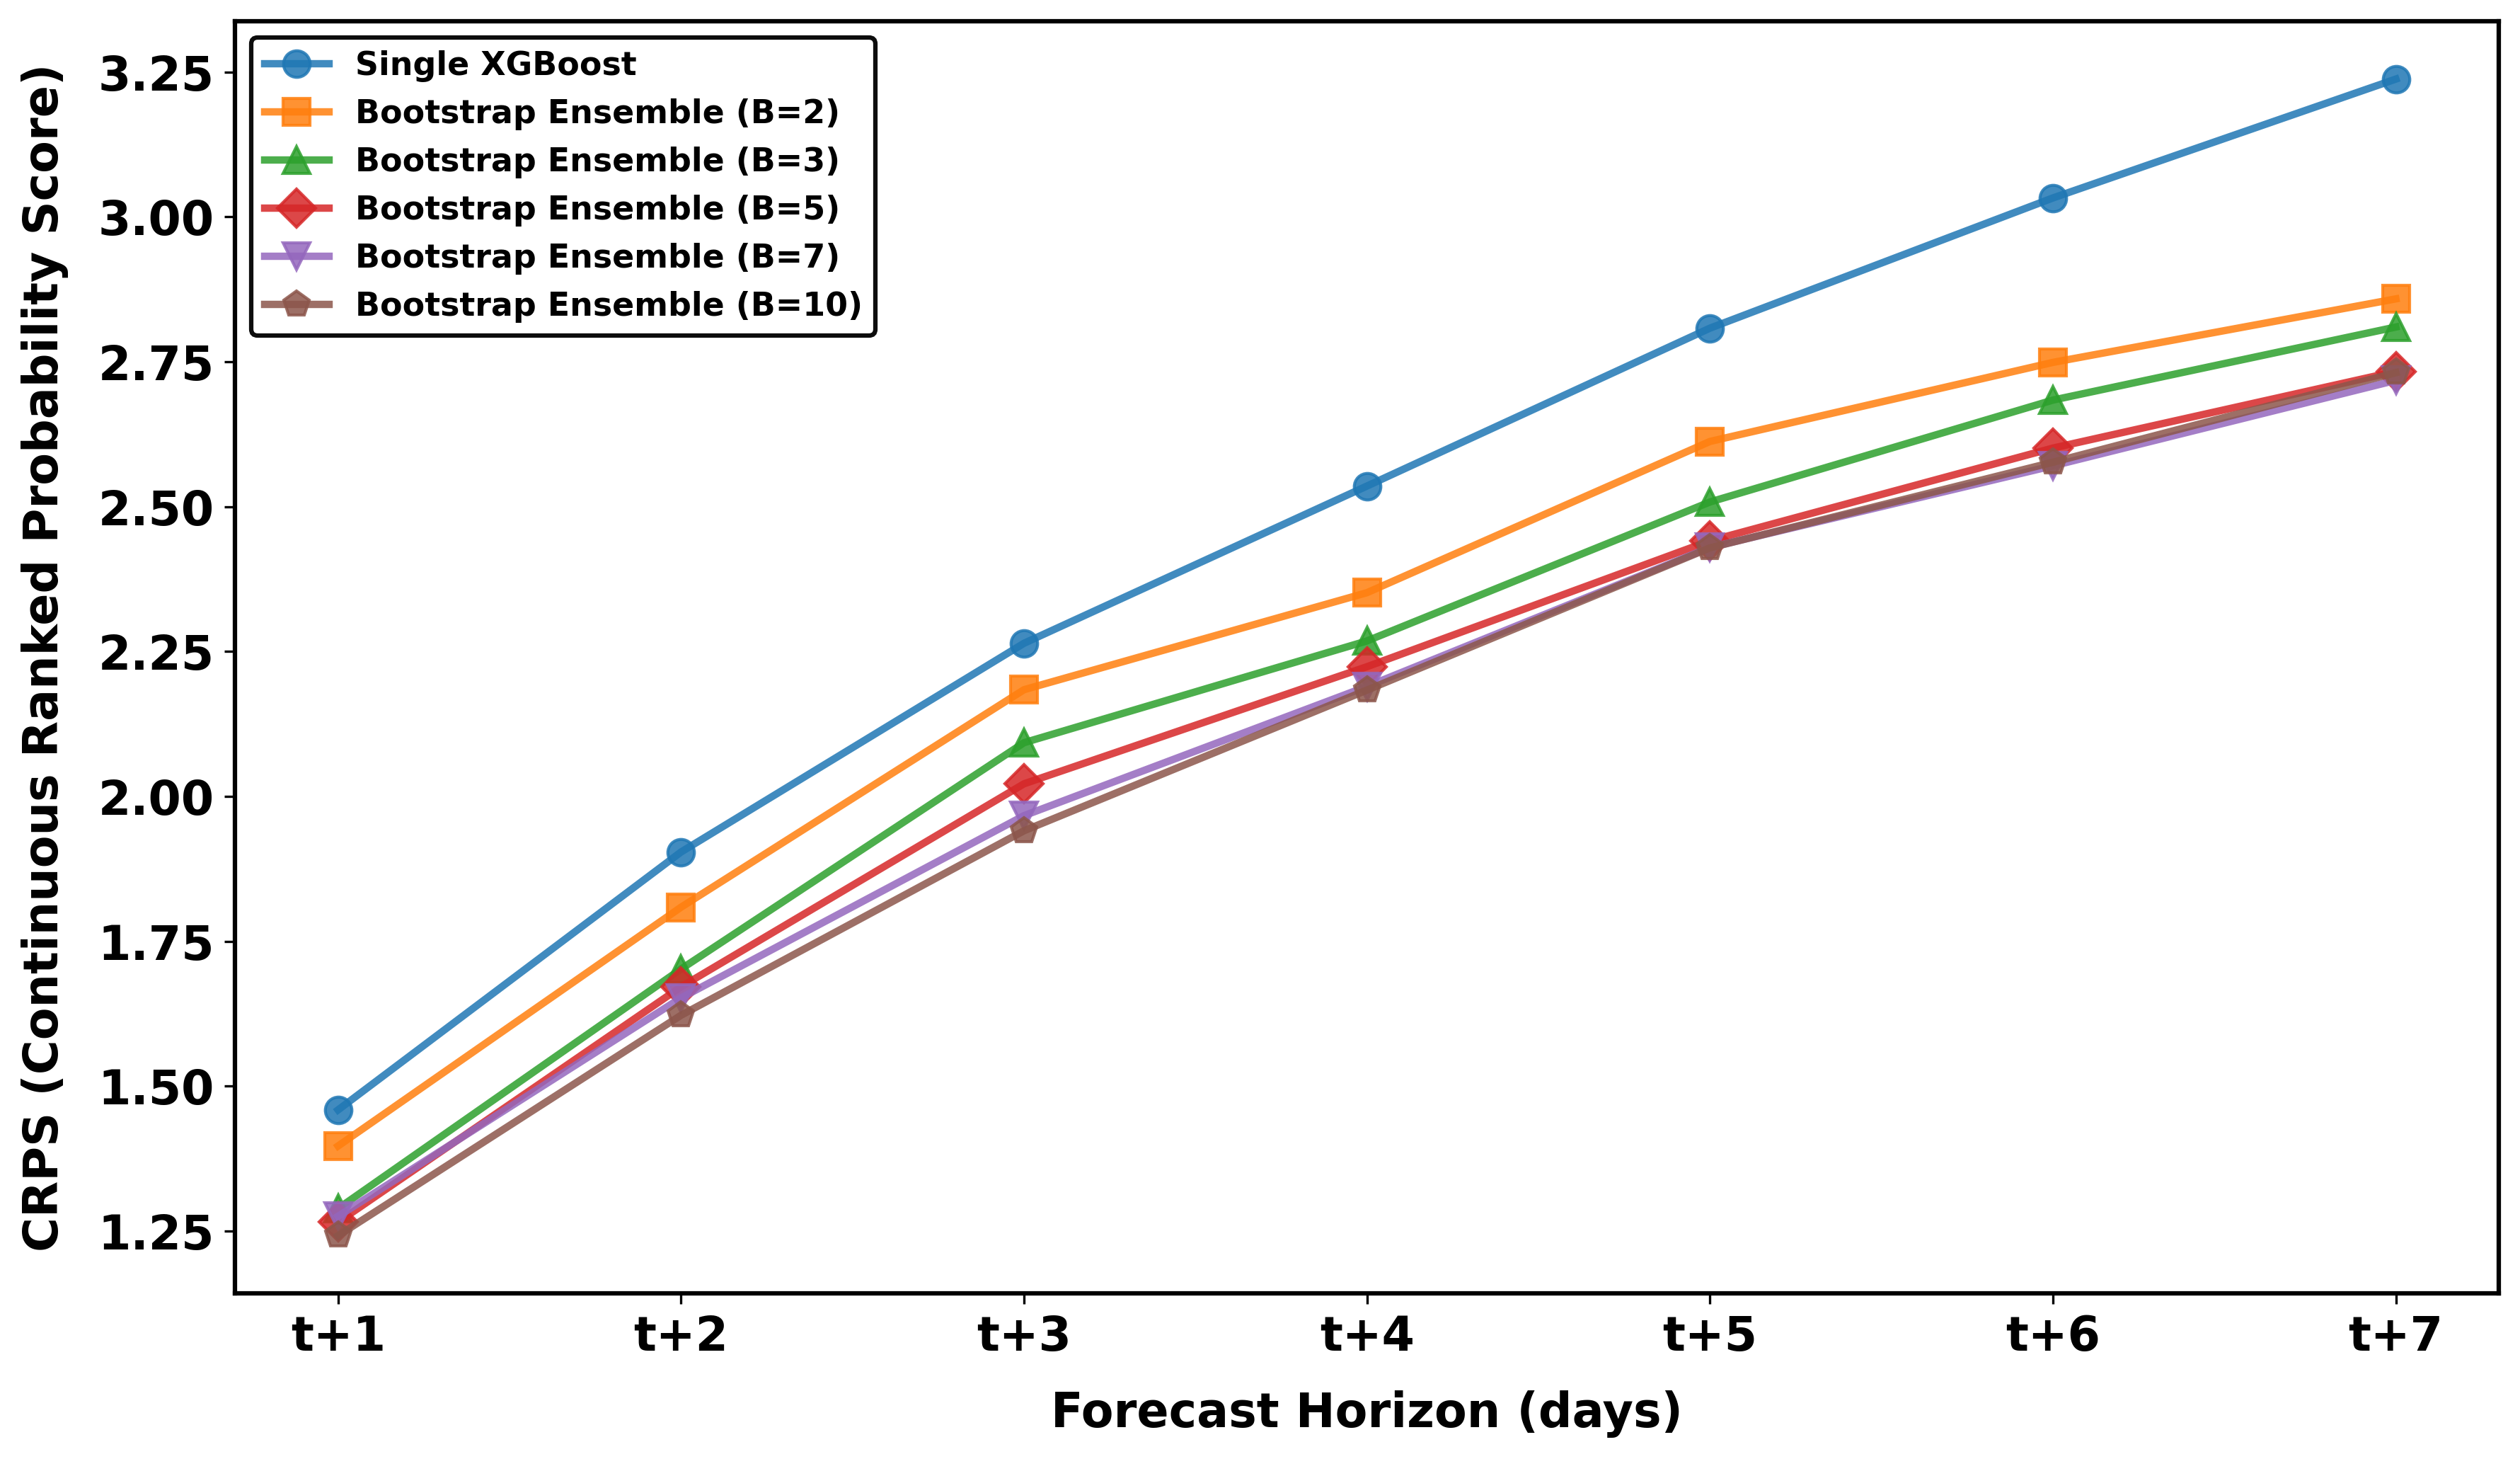

 Saved: ./BVR_Forecasting_Results/uq_bootstrap_ensemble_crps.png

 FILES GENERATED:
 1. uq_bootstrap_ensemble_crps.png
 UNCERTAINTY QUANTIFICATION ANALYSIS COMPLETE


In [11]:
# ------------------------------------------------------------
# UNCERTAINTY QUANTIFICATION - BOOTSTRAP ENSEMBLE UNCERTAINTY
# ------------------------------------------------------------
# PURPOSE: Uncertainty evaluation using CRPS
# Bootstrap Ensemble - Epistemic uncertainty via data resampling (B=1,2,3,5,7,10)
# ------------------------------------------------------------

print(" UNCERTAINTY QUANTIFICATION: BOOTSTRAP ENSEMBLE UNCERTAINTY")
print("\n Methods:")
print(" 1. Bootstrap Ensemble (B=1, 2, 3, 5, 7, 10)")
print("\n Evaluation: CRPS (Continuous Ranked Probability Score)")


# ============================================================================
# Helper Functions (CRPS Calculations)
# ============================================================================

def crps_ensemble_vec(preds_2d, obs_1d):
    """
    Vectorized CRPS for ensemble predictions.

    CRPS = E[|X - y|] - 0.5 * E[|X - X'|]

    This is the standard ensemble CRPS formula for probabilistic forecasts.

    Reference: Hersbach (2000) - "Decomposition of the CRPS"

    Parameters:
    -----------
    preds_2d : array (N, B) - Ensemble predictions (N samples, B ensemble members)
    obs_1d : array (N,) - Observed values

    Returns:
    --------
    array (N,) - CRPS per sample
    """
    P = np.asarray(preds_2d) # (N, B)
    y = np.asarray(obs_1d) # (N,)


    term1 = np.mean(np.abs(P - y[:, None]), axis=1)
    diffs = np.abs(P[:, :, None] - P[:, None, :])
    term2 = np.mean(diffs, axis=(1, 2))

    return term1 - 0.5 * term2

print(" Helper functions defined (CRPS calculations)")

# ============================================================================
# Configuration
# ============================================================================

# Bootstrap ensemble sizes
B_LIST = [1, 2, 3, 5, 7, 10]



print(f"\n Configuration:")
print(f" Bootstrap sizes: {B_LIST}")
print(f" Forecast horizons: {FORECAST_HORIZONS}")
print(f" Random seed: {SEED}")

# Storage for results
crps_dict = {}
crps_samples_dict = {}

N_test = len(X_test_processed)

# ============================================================================
# BOOTSTRAP ENSEMBLE
# ============================================================================

print("BOOTSTRAP ENSEMBLE")

for B in B_LIST:
    if B == 1:
        print(f"\n Using Existing Single XGBoost Model...")
        model_single = None

        model_single = final_model

        # Use existing model
        all_preds = np.zeros((N_test, FORECAST_HORIZONS, 1), dtype=np.float32)
        all_preds[:, :, 0] = model_single.predict(X_test_processed)

    else:
        print(f"\n Bootstrap Ensemble (B={B})...")

        all_preds = np.zeros((N_test, FORECAST_HORIZONS, B), dtype=np.float32)

        for b in range(B):
            # Resample training data with replacement
            X_boot, y_boot = resample(
                X_train_processed, y_train,
                replace=True, random_state=SEED + b
            )

            # Train model on resampled data
            model_boot = MultiOutputRegressor(
                xgb.XGBRegressor(**best_params, random_state=SEED + b, n_jobs=1)
            )
            model_boot.fit(X_boot, y_boot)
            all_preds[:, :, b] = model_boot.predict(X_test_processed)

            if (b + 1) % 5 == 0 or (b + 1) == B:
                print(f" {b+1}/{B} models trained...")

    # Compute CRPS for this bootstrap size
    crps_b = []
    crps_b_per_sample = np.zeros((N_test, FORECAST_HORIZONS), dtype=np.float32)

    for h in range(FORECAST_HORIZONS):
        # For B=1, CRPS reduces to MAE (single prediction)
        if B == 1:
            vals = np.abs(all_preds[:, h, 0] - y_test.iloc[:, h].values)
        else:
            vals = crps_ensemble_vec(all_preds[:, h, :], y_test.iloc[:, h].values)

        crps_b.append(float(vals.mean()))
        crps_b_per_sample[:, h] = vals

    # Label: B=1 is "Single XGBoost", B>1 is "Bootstrap Ensemble (B=X)"
    if B == 1:
        label = "Single XGBoost"
    else:
        label = f"Bootstrap Ensemble (B={B})"

    crps_dict[label] = crps_b
    crps_samples_dict[label] = crps_b_per_sample

    print(f" CRPS (mean): {np.mean(crps_b):.4f}")

print(f"\n Bootstrap ensemble analysis complete")

# ============================================================================
# VISUALIZATION: CRPS Comparison
# ============================================================================

print(" GENERATING COMPARISON FIGURE")


# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.5,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Color scheme
colors_bootstrap = {
    1: '#1f77b4', # Blue
    2: '#ff7f0e', # Orange
    3: '#2ca02c', # Green
    5: '#d62728', # Red
    7: '#9467bd', # Purple
    10: '#8c564b' # Brown
}

markers_bootstrap = {
    1: 'o',
    2: 's',
    3: '^',
    5: 'D',
    7: 'v',
    10: 'p'
}

horiz = np.arange(1, FORECAST_HORIZONS + 1)

# Plot Bootstrap ensembles
for B in B_LIST:
    if B == 1:
        label = "Single XGBoost"
    else:
        label = f"Bootstrap Ensemble (B={B})"

    if label in crps_dict:
        ax.plot(
            horiz, crps_dict[label],
            marker=markers_bootstrap[B],
            linewidth=2.5,
            markersize=9,
            label=label,
            color=colors_bootstrap[B],
            alpha=0.85,
            zorder=2
        )


# Styling
ax.set_xticks(horiz)
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')
ax.set_xticklabels([f"t+{h}" for h in horiz], fontsize=16, fontweight='bold')
ax.set_xlabel('Forecast Horizon (days)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('CRPS (Continuous Ranked Probability Score)',
              fontsize=16, fontweight='bold', labelpad=10)
#             fontsize=14, fontweight='bold', pad=15)

# Grid and spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# Legend
leg = ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fontsize=11,
    loc='best',
    framealpha=0.95,
    ncol=1
)

# Make legend text bold
for text in leg.get_texts():
    text.set_fontweight('bold')

leg.get_frame().set_linewidth(1.5)


plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/uq_bootstrap_ensemble_crps.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f" Saved: {OUTPUT_DIR}/uq_bootstrap_ensemble_crps.png")
print(f"\n FILES GENERATED:")
print(f" 1. uq_bootstrap_ensemble_crps.png")
print(" UNCERTAINTY QUANTIFICATION ANALYSIS COMPLETE")

## 11. Optimizing the evaultion figures for paper

Side-by-side RMSE vs horizon and CRPS vs horizon.

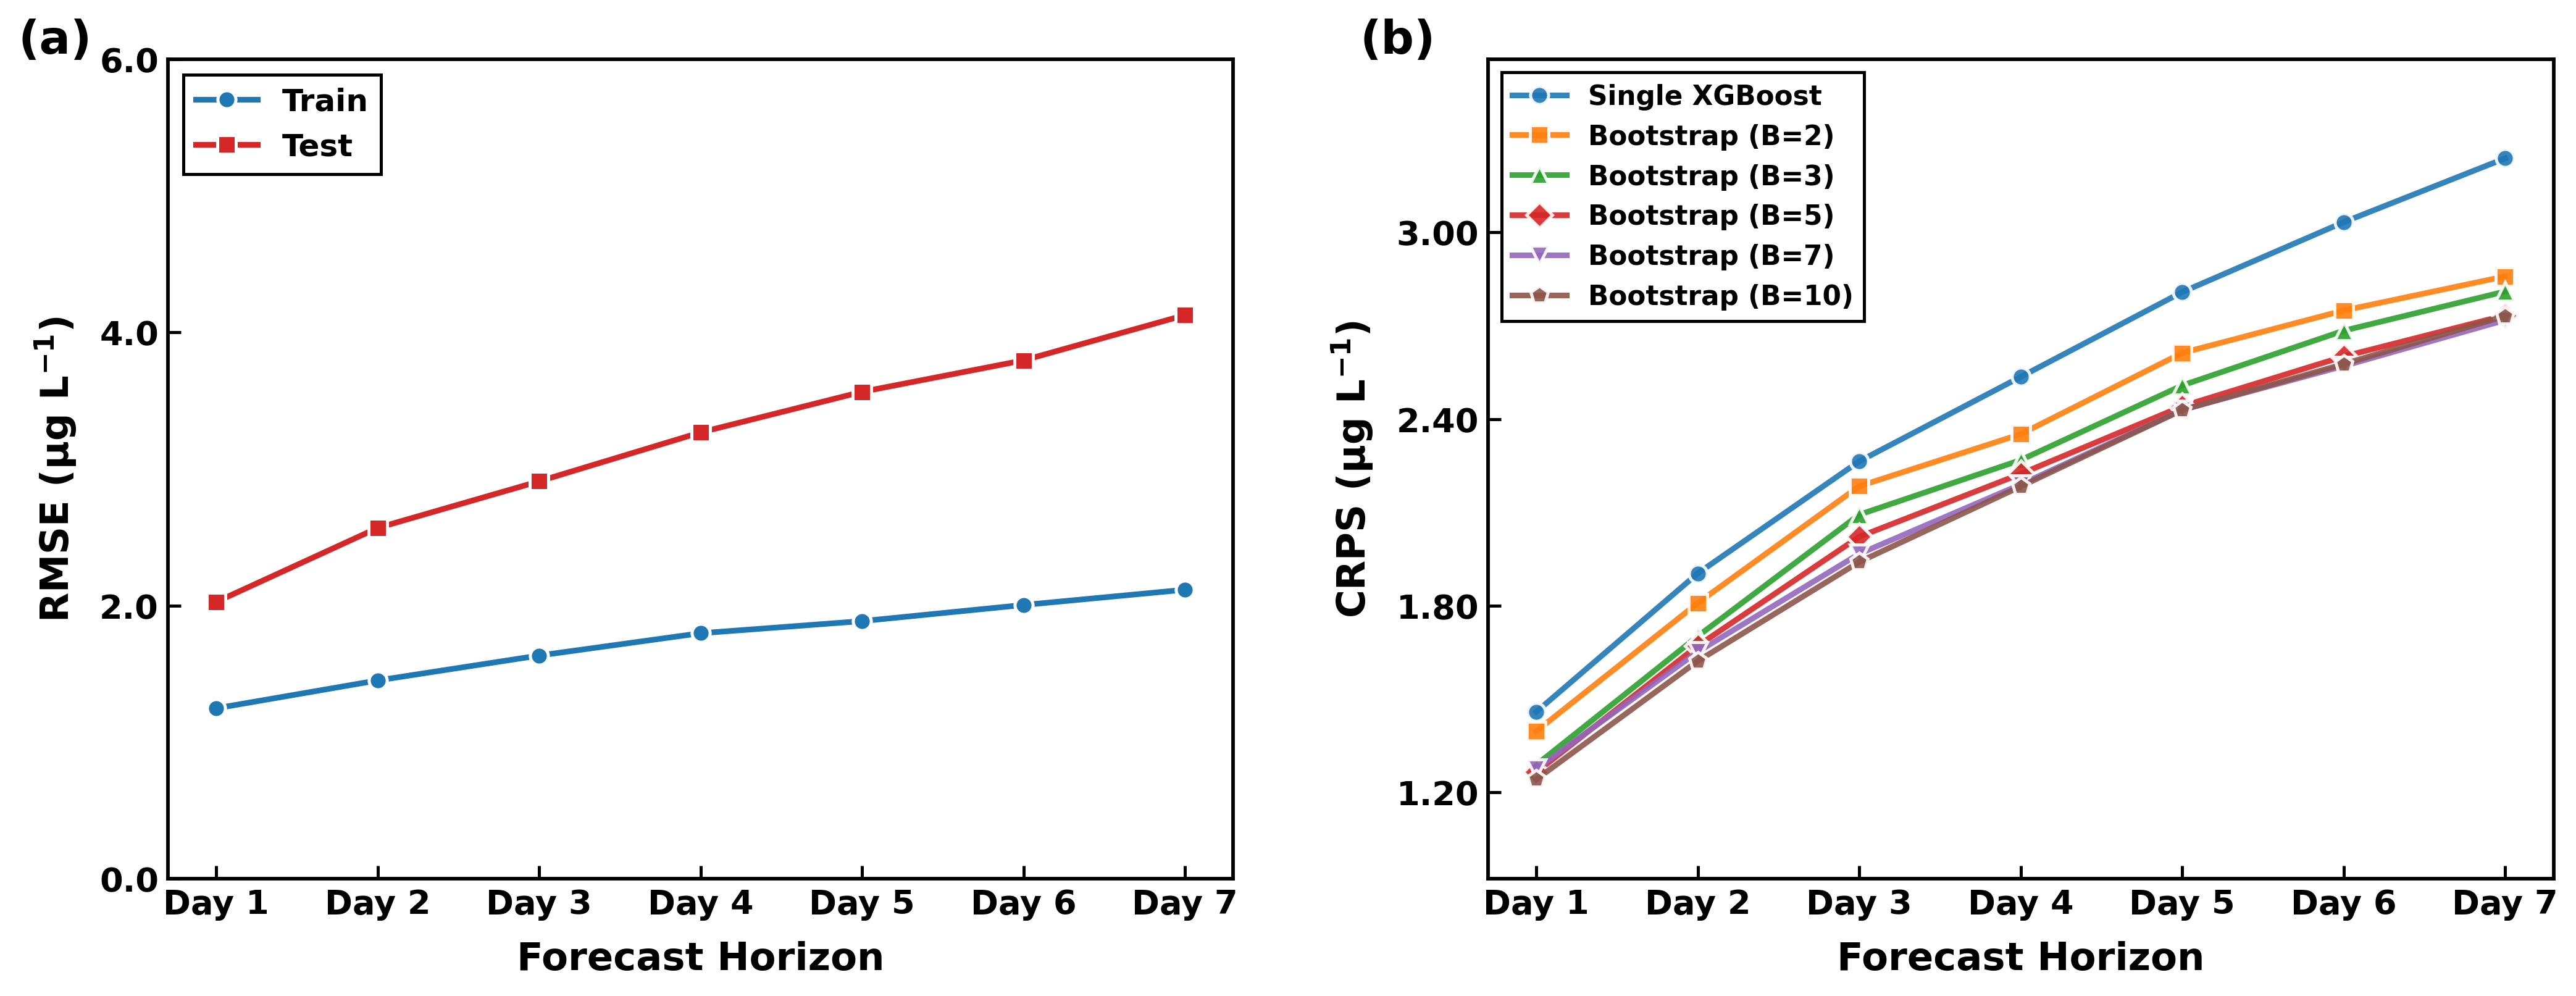

Saved: ./BVR_Forecasting_Results/rmse_bootstrap_crps_vs_horizon.png


In [12]:
# ============================================================================
# PUBLICATION FIGURE: RMSE vs Horizon  |  Bootstrap Ensemble CRPS vs Horizon
# ============================================================================


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.default': 'regular',
    'axes.linewidth': 1.4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

horizons = np.arange(1, FORECAST_HORIZONS + 1)
h_labels = [f'Day {i}' for i in horizons]

# ── Panel (a): RMSE vs Forecast Horizon (Train & Test) ──────────────────────

ax1.plot(horizons, train_rmse,
         color='#1f77b4', linewidth=2.2, marker='o', markersize=7,
         markeredgecolor='white', markeredgewidth=1.2,
         label='Train', zorder=3)
ax1.plot(horizons, test_rmse,
         color='#d62728', linewidth=2.2, marker='s', markersize=7,
         markeredgecolor='white', markeredgewidth=1.2,
         label='Test', zorder=3)


ax1.set_xticks(horizons)
ax1.set_xticklabels(h_labels, fontsize=13, fontweight='bold')
ax1.set_xlabel('Forecast Horizon', fontsize=15, fontweight='bold', labelpad=8)
ax1.set_ylabel('RMSE (µg L$^{-1}$)', fontsize=15, fontweight='bold', labelpad=8)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

for lab in ax1.get_yticklabels():
    lab.set_fontsize(13)
    lab.set_fontweight('bold')

leg1 = ax1.legend(frameon=True, fontsize=12, loc='upper left',
                  edgecolor='black', fancybox=False, framealpha=1)
leg1.get_frame().set_linewidth(1.2)
for t in leg1.get_texts():
    t.set_fontweight('bold')

ax1.text(-0.14, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=18, fontweight='bold', va='top')

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.4)
    spine.set_edgecolor('black')

# ── Panel (b): Bootstrap Ensemble CRPS vs Forecast Horizon ──────────────────

palette = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c',
           5: '#d62728', 7: '#9467bd', 10: '#8c564b'}
markers = {1: 'o', 2: 's', 3: '^', 5: 'D', 7: 'v', 10: 'p'}

for B in B_LIST:
    lab = 'Single XGBoost' if B == 1 else f'Bootstrap (B={B})'
    key = 'Single XGBoost' if B == 1 else f'Bootstrap Ensemble (B={B})'
    if key in crps_dict:
        ax2.plot(horizons, crps_dict[key],
                 color=palette[B], linewidth=2.2,
                 marker=markers[B], markersize=7,
                 markeredgecolor='white', markeredgewidth=1.2,
                 label=lab, alpha=0.9, zorder=3)

ax2.set_xticks(horizons)
ax2.set_xticklabels(h_labels, fontsize=13, fontweight='bold')
ax2.set_xlabel('Forecast Horizon', fontsize=15, fontweight='bold', labelpad=8)
ax2.set_ylabel('CRPS (µg L$^{-1}$)', fontsize=15, fontweight='bold', labelpad=8)

for lab in ax2.get_yticklabels():
    lab.set_fontsize(13)
    lab.set_fontweight('bold')

leg2 = ax2.legend(frameon=True, fontsize=10.5, loc='upper left',
                  edgecolor='black', fancybox=False, framealpha=1, ncol=1)
leg2.get_frame().set_linewidth(1.2)
for t in leg2.get_texts():
    t.set_fontweight('bold')

ax2.text(-0.12, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=18, fontweight='bold', va='top')

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.4)
    spine.set_edgecolor('black')

# ── Independent Y-Axes for Clarity ──
# ── Y-axis config for Panel (a)
RMSE_Y_MIN      = 0.0   # lower y-limit for RMSE panel
RMSE_Y_MAX      = 6.0   # upper y-limit for RMSE panel
RMSE_Y_INTERVAL = 2.0   # tick interval for RMSE panel

ax1.set_ylim(RMSE_Y_MIN, RMSE_Y_MAX)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(RMSE_Y_INTERVAL))


# CRPS (Panel B): Independent limits to visualize narrow differences
y2_min, y2_max = ax2.get_ylim()
y2_margin = (y2_max - y2_min) * 0.10
ax2.set_ylim(max(0, y2_min - y2_margin), y2_max + y2_margin)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))


plt.tight_layout(w_pad=3.0)
save_path = f'{OUTPUT_DIR}/rmse_bootstrap_crps_vs_horizon.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {save_path}')